# 😊 모듈 임포트 

In [1]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, PreTrainedTokenizerFast, TrainingArguments, Trainer
import inspect
import pandas as pd
import types
import numpy
import time
import json
import sys
import os
import gc
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
from datasets import load_dataset
from deep_translator import GoogleTranslator
from tqdm.notebook import tqdm
import logging
import copy

print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 파이썬 경로에 상위 폴더를 추가하여 chatgpt 모듈을 찾을 수 있게 합니다.
sys.path.append(os.path.abspath('..'))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요.
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.6.0+cu124
Cuda version: 12.4
transformers version: 5.3.0
GPU 사용 가능여부: True


### 👻 메모리 영혼 탈곡기

In [2]:
def deep_clean_gpu(vars_to_keep=None):
    """
    삭제할 변수가 있으면 확인 후 삭제하고, 
    변수가 없더라도 가비지 컬렉션과 GPU 캐시 비우기는 무조건 수행합니다.
    """
    if vars_to_keep is None:
        vars_to_keep = []
    
    # ---------------------------------------------------------
    # 1. 삭제 후보 자동 탐색
    # ---------------------------------------------------------
    keywords = ['model', 'trainer', 'optimizer', 'logits', 'loss']
    hard_targets = ['outputs', 'input_ids', 'labels', 'predictions']
    
    found_candidates = []
    for var_name in list(globals().keys()):
        # 1. 시스템 내부 변수(__로 시작) 제외
        if var_name.startswith('_'):
            continue
            
        # 2. 보존 목록에 있으면 제외
        if var_name in vars_to_keep:
            continue
            
        # 3. 핵심 수정 사항: '클래스'나 '모듈'인 경우 삭제 대상에서 제외
        obj = globals().get(var_name)
        if inspect.isclass(obj) or isinstance(obj, types.ModuleType):
            continue
            
        # 4. 이름 기반 필터링
        if any(k in var_name.lower() for k in keywords) or (var_name in hard_targets):
            found_candidates.append(var_name)
    
    delete_list = sorted(list(set(found_candidates)))
    proceed_delete = False

    # ---------------------------------------------------------
    # 2. 삭제 변수가 있을 때만 확인 절차 진행
    # ---------------------------------------------------------
    if delete_list:
        print("🔎 [GPU 메모리 삭제 후보 탐색 결과]")
        print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print(f"🗑️ 삭제 대상: {', '.join(delete_list)}")
        print(f"🛡️ 보존 대상: {', '.join(vars_to_keep) if vars_to_keep else '없음'}")
        print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        
        confirm = input("\n❗ 위 변수들을 삭제하시겠습니까? (y/n): ").lower()
        if confirm == 'y':
            proceed_delete = True
        else:
            print("⚠️ 변수 삭제는 취소되었습니다. 캐시 정리만 진행합니다.")
    else:
        print("✅ 삭제할 변수 지정을 탐색하지 못했습니다. 캐시 정리로 넘어갑니다.")

    # ---------------------------------------------------------
    # 3. 실제 청소 작업 시작 (무조건 실행됨)
    # ---------------------------------------------------------
    print("\n🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...")
    
    allocated_before = torch.cuda.memory_allocated() / (1024**3)
    reserved_before = torch.cuda.memory_reserved() / (1024 ** 3)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3

    # 변수 삭제 실행 (사용자가 y를 눌렀을 때만)
    deleted_vars = []
    if proceed_delete:
        for var in delete_list:
            if var in globals():
                del globals()[var]
                deleted_vars.append(var)
    
    # 🧹 변수 삭제 여부와 상관없이 무조건 실행되는 핵심 청소
    gc.collect()
    torch.cuda.empty_cache()
    
    # ---------------------------------------------------------
    # 4. 결과 보고
    # ---------------------------------------------------------
    allocated_after = torch.cuda.memory_allocated() / (1024**3)
    reserved_after = torch.cuda.memory_reserved() / (1024 ** 3)
    
    print("\n✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과")
    print(f"📝 VRAM 장치 총량: {vram_total:.1f}GB")
    print(f"🔥 실사용 메모리: {allocated_before:.2f}GB -> {allocated_after:.2f}GB")
    print(f"🛒 캐시 예약 메모리: {reserved_before:.2f}GB -> {reserved_after:.2f}GB")
    
    print("\n🖥️ 시스템 nvidia-smi 현황")
    get_ipython().system('nvidia-smi | grep "MiB /"')

    if deleted_vars:
        print(f"\n✅ 삭제 완료된 변수: {', '.join(deleted_vars)}")


In [28]:
# deep_clean_gpu(vars_to_keep=['tokenizer']) # 토크나이저는 가벼우니 남겨두고 다 지워라!
deep_clean_gpu()

🔎 [GPU 메모리 삭제 후보 탐색 결과]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗑️ 삭제 대상: loss, optimizer, rm_model, rm_model_name, total_loss
🛡️ 보존 대상: 없음
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️ 변수 삭제는 취소되었습니다. 캐시 정리만 진행합니다.

🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...

✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과
📝 VRAM 장치 총량: 8.0GB
🔥 실사용 메모리: 1.22GB -> 1.22GB
🛒 캐시 예약 메모리: 1.49GB -> 1.47GB

🖥️ 시스템 nvidia-smi 현황
|  0%   46C    P2             80W /  310W |    3111MiB /   8192MiB |      1%      Default |


> 허깅페이스의 transformers를 사용하여 토크나이저와 KoGPT-2 불러오기

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
# 이 토크나이저를 사용해야 한국어가 깨지지 않습니다!
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    model_name,
    bos_token='</s>', 
    eos_token='</s>', 
    unk_token='<unk>', 
    pad_token='<pad>', 
    mask_token='<mask>',
    padding_side="right",
    model_max_length=512
)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


> 토크나이징 방식 확인

In [9]:
input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

In [10]:
pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


> 디코딩 성능 확인

In [11]:
max_length=128
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


> 빔 서치 디코딩 사용, n-gram 패널티 부과

In [12]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


> 샘플링 기법 추가
- temperature 값을 낮추면(예: temperature=0.5) 확률이 높은 단어들이 더욱 우세하게 선택되며, 보수적인 생성이 이루어집니다.
- 반대로 값을 높이면(예: temperature=1.5) 확률이 낮은 단어들도 더 자주 선택되며, 더 창의적이지만 불안정한 결과가 나올 수 있습니다.
- top_k=50이면, 확률이 높은 상위 50개의 단어만 샘플링 대상이 되고, 그 외 단어는 제외

In [13]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"아무튼 그건 그렇고요."
"이제 더 이상 할 말은 없습니다."
그녀는 고개를 끄덕였다.
"그런데 무슨 말이 필요하겠습니까?"
그러는 사이 그녀는 입을 다물었다.
"자세히 말해 줄 수 있겠습니까."
"글쎄요, 저는 그걸 모를 뿐입니다."
그러나 그녀는 입술을 꼭 깨물며 말했다.
"그래요? 그럴 필요는 없을 것 같군요. 아무튼 제 말은 잘 들리겠죠."
그녀의 눈빛이 날카로워


> top_p는 Nucleus Sampling이라고도 불리며, 단어 선택 시 확률 누적 기준으로 상위 p%의 단어들만 고려하는 방법입니다.

In [14]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그렇지 않습니다."
그제야 나는 고개를 끄덕였다.
"어떻게 된 일입니까?"
나는 한숨을 내쉬었다.
"아니야. 그게 무슨 소리예요? 그건 알 수가 없는데."
"말도 안 되는 소리입니다."
내가 다시 물었다.
"그러니까, 그걸 어떻게 알았느냐고요."
그러자 그제서야 나는 입을 다물고 말았다.
"뭐라고 했지? 무슨 말인지 알 수 없잖아."
나는 고개를 저


>SFT를 시도할 initial 모델에 쓸 데이터셋

In [15]:
import json
data_path_1_SFT = '../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

## 📝 Phase 1: 평가 기반 마련 및 베이스라인 측정

### 🕊️ BLEU, ROUGE 정량평가

In [17]:
# 필요시 주석 해제하여 라이브러리 설치 (최초 1회)
# !pip install rouge_score nltk

import nltk
from tqdm.notebook import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# NLTK 리소스 다운로드 (최초 1회 실행 필요)
# nltk.download('punkt')

# [추가된 부분] 평가를 위한 범용 함수 정의 (재사용 가능하도록 설계)
# [추가된 부분] 첫 5개의 응답을 눈으로 확인하기 위해 출력 기능(num_print_samples=3) 추가
def calculate_metrics(model, tokenizer, dataset, generation_args, prompt_dict, num_samples=50, num_print_samples=3):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothie = SmoothingFunction().method4

    total_bleu = 0
    total_rouge1 = 0
    total_rouge2 = 0
    total_rougeL = 0

    samples = dataset[:num_samples]

    for i, example in enumerate(tqdm(samples, desc="Calculating Metrics")):
        prompt_text = example['prompt']
        reference = example['completion']

        # 프롬프트 구성
        formatted_prompt = prompt_dict['prompt_input'].format_map({'prompt': prompt_text})

        # 모델 인퍼런스
        input_ids = tokenizer(formatted_prompt, return_tensors="pt")["input_ids"].to(device)
        
        with torch.no_grad(): # 평가 시에는 기울기 계산을 하지 않음 (메모리 절약)
            output_ids = model.generate(input_ids, **generation_args)
        
        # 생성된 전체 텍스트 디코딩
        # generated_full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        
        # 프롬프트 부분을 제외하고 모델이 생성한 실제 답변만 추출
        # 수정 전 (문자열 매칭 방식 - ❌ 비추천)
        # generated_full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        # if "### Response(응답):" in generated_full_text:
        #     generated_answer = generated_full_text.split("### Response(응답):")[-1].strip()

        # 수정 후 (텐서 슬라이싱 방식 - ✅ 추천)
        input_len = input_ids.shape[1]  # 내가 질문한 토큰의 개수를 미리 잽니다.
        # 결과물(output_ids)에서 질문 길이 이후의 '새로 생성된 숫자들'만 가져옵니다.
        generated_answer_ids = output_ids[0][input_len:] 
        # 그리고 그 순수한 정답 숫자들만 글자로 바꿉니다.
        generated_answer = tokenizer.decode(generated_answer_ids, skip_special_tokens=True).strip()

        # ----------------------------------------------------
        # 🔥 이 부분 추가! 첫 3개의 텍스트를 눈으로 직접 확인
        if i < num_print_samples:
            print(f"\n\n--- [샘플 {i+1} 눈으로 확인하기] ---")
            print(f"👤 사용자 프롬프트 : {prompt_text}")
            print(f"📖 실제 정답 (Ref) : {reference}")
            print(f"🤖 모델 생성 (Pred): {generated_answer}")
            print("-" * 40)
        # ----------------------------------------------------

        # BLEU 계산 (단어 띄어쓰기 기준)
        ref_tokens = reference.split()
        gen_tokens = generated_answer.split()
        bleu = sentence_bleu([ref_tokens], gen_tokens, smoothing_function=smoothie)

        # ROUGE 계산
        rouge_scores = scorer.score(reference, generated_answer)

        total_bleu += bleu
        total_rouge1 += rouge_scores['rouge1'].fmeasure
        total_rouge2 += rouge_scores['rouge2'].fmeasure
        total_rougeL += rouge_scores['rougeL'].fmeasure

    # 평균 계산
    avg_bleu = total_bleu / num_samples
    avg_rouge1 = total_rouge1 / num_samples
    avg_rouge2 = total_rouge2 / num_samples
    avg_rougeL = total_rougeL / num_samples

    print(f"\n[Metric Results - {num_samples} samples]")
    print(f"BLEU Score : {avg_bleu:.4f}")
    print(f"ROUGE-1 F1 : {avg_rouge1:.4f}")
    print(f"ROUGE-2 F1 : {avg_rouge2:.4f}")
    print(f"ROUGE-L F1 : {avg_rougeL:.4f}")

    return avg_bleu, avg_rouge1, avg_rouge2, avg_rougeL

In [18]:
# ------------------------------------------------------------------
# 평가 환경 셋업 (외부 변수로 분리하여 유지보수성 향상)
# ------------------------------------------------------------------
eval_prompt_dict = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

eval_generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=tokenizer.eos_token_id, # tokenizer 내장 eos 사용
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

# [중요] 현재 메모리에 올라와 있는 모델(Cell 2에서 부른 순정 KoGPT-2)로 베이스라인 측정!
print("=== [루브릭1] 순정 KoGPT-2 (Pretrained) Baseline 측정 ===")
base_metrics = calculate_metrics(
    model=model, 
    tokenizer=tokenizer, 
    dataset=list_data_dict, 
    generation_args=eval_generation_args, 
    prompt_dict=eval_prompt_dict, 
    num_samples=50 # 전체 12,000개는 너무 기니까 50개만 샘플링
)

=== [루브릭1] 순정 KoGPT-2 (Pretrained) Baseline 측정 ===


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): #foodporn #delicious #instadaily #like4like #소통 #좋아요
#팔로우 #맞팔 #선팔 #일상 #데일리 #먹방 #먹
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): #Reports(선택):
#Identity(목적):
#instaficial(정보):
#realize(검색):
#Realize (추천):
#Simulator(추천): #다이어트
----------------------------------------


--- [샘플 3 눈으로 확인하기] ---
👤 사용자 프롬프트 : 여친이랑 다툼
📖 실제 정답 (R

> RM에 사용할 데이터셋

In [19]:
data_path_2_RM = '../KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

> PPO 학습에 쓰일 데이터

In [20]:
data_path_3_PPO = '../KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

# Supervised Fine-Tuning

> 모델 인퍼런스 단계에서 사용할 prompt 딕셔너리 템플릿과 SFT 데이터셋 클래스를 정의

In [21]:

class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, prompt_dict, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        self.prompt_input = prompt_dict["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = self.prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [22]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

 > SFT_dataset 클래스를 사용해 훈련셋을 만들고 data collator 인스턴스를 만듭니다.

In [23]:
train_dataset = SFT_dataset(data_path_1_SFT=data_path_1_SFT, tokenizer=tokenizer, prompt_dict=eval_prompt_dict)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

# print('input : %s'%train_dataset.input_ids[0])
# print('output: %s'%train_dataset.labels[0])

> Training arguments를 사용해 trainer 클래스를 정의

<details>
<summary>TrainingArguments 인자 기능</summary>
<div markdown="1">

**주요 기능**

`output_dir` : 모델, 체크포인트, 로그 등 모든 결과물을 저장할 경로를 지정합니다.

`per_device_train_batch_size / per_device_eval_batch_size` : 각 디바이스(GPU/CPU)에서 사용하는 배치 사이즈로, 학습 속도와 메모리 사용량에 큰 영향을 줍니다.
n`learning_rate` : 학습의 시작 속도를 결정하는 핵심 하이퍼파라미터로, 모델 성능에 직접적인 영향을 미칩니다.

`num_train_epochs / max_steps` : 학습의 총 반복 횟수를 결정합니다. max_steps가 설정되면 num_train_epochs는 무시되므로, 둘 중 하나만 신경 쓰면 됩니다.

`warmup_steps / warmup_ratio` : 학습 초기 안정화를 위해 학습률을 서서히 증가시키는 단계로, 옵티마이저의 성능과 학습 안정성에 도움을 줍니다.

`evaluation_strategy` : 학습 도중 평가를 수행하는 빈도를 결정합니다. (예: "steps" 또는 "epoch")
주의: 너무 잦은 평가가 학습 속도를 늦출 수 있으니 적절한 주기를 선택해야 합니다.

`save_steps` : 체크포인트 저장 주기를 정합니다. 디스크 사용량과 복구 지점을 고려할 때 중요한 옵션입니다.

`logging_steps` : 학습 진행 상황을 기록할 주기를 설정합니다. 디버깅이나 모니터링에 필수적입니다.

`fp16` : 16비트 부동소수점 연산(FP16)을 활성화해 메모리 사용량과 학습 속도를 최적화할 수 있습니다. 다만, 모든 환경에서 안정적인 결과를 보장하지 않을 수 있으니 주의가 필요합니다.

</div>
</details>

In [24]:
training_args = transformers.TrainingArguments(
    output_dir="test",
    num_train_epochs=1,
    per_device_train_batch_size=2,        # 기존 8 -> 4 -> 2로 줄임! (VRAM 여유 확보)
    gradient_accumulation_steps=4,        # 배치 사이즈를 줄인 대신, 4번 모아서 학습하게 하여 기존 8과 동일한 효과를 냄!
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,
    
    # 데이터 로딩 최적화 (여기에 추가하세요)
    dataloader_num_workers=4, 
    dataloader_pin_memory=True
)
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

### 😺 SFT 학습 진행 (1epoch)

In [25]:
trainer.train()
model.save_pretrained('models/output_1_SFT')
tokenizer.save_pretrained('models/output_1_SFT')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,2.979449
1000,2.783956
1500,2.686009


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/output_1_SFT/tokenizer_config.json',
 'models/output_1_SFT/tokenizer.json')

> 허깅페이스의 pipeline 클래스를 사용하여 generator 만들어보기

<details>
<summary>주요 Generation Options</summary>
<div markdown="1">



`max_length` : 생성할 텍스트의 최대 길이를 지정합니다. 단, 너무 큰 값은 불필요한 계산을 유발할 수 있습니다.

`min_length` : 생성 텍스트의 최소 길이를 보장합니다.

`do_sample` : 샘플링을 사용할지 여부를 결정합니다. False일 경우 greedy search 혹은 beam search 등 결정론적 방법을 사용합니다.

`num_beams` : beam search 시 고려할 빔의 수를 지정합니다. 값이 클수록 더 다양한 후보를 고려하지만, 계산 비용이 증가합니다.

`temperature` : 샘플링 시 확률 분포의 평탄화 정도를 조절합니다. 낮은 값은 확률 분포를 예리하게 만들어, 높은 값은 다양성을 증가시킵니다.

`top_k` : 샘플링 시 고려할 상위 k개의 후보 토큰만 사용합니다. 높은 값은 다양한 결과를, 낮은 값은 집중된 선택을 유도합니다.

`top_p` (nucleus sampling) : 확률 누적 합이 p에 도달할 때까지의 후보 토큰을 사용합니다. 후보 집합의 크기를 동적으로 조절해, 확률이 낮은 토큰은 배제합니다.

`repetition_penalty` : 동일한 문구나 단어의 반복 생성을 방지합니다. 값이 1보다 크면 반복에 패널티를 부여합니다.

`length_penalty` : beam search 시 문장 길이에 대한 보정을 합니다. 값이 1보다 크면 긴 문장을 선호, 작으면 짧은 문장을 선호합니다.

`no_repeat_ngram_size` : 지정한 크기의 n-그램이 반복되지 않도록 합니다. 예를 들어, 3을 설정하면 동일한 3-그램이 여러 번 등장하지 않습니다.

`early_stopping` : 모든 beam에서 EOS 토큰이 생성되면 조기 종료합니다.

`bad_words_ids` : 생성 과정에서 금지된 단어들의 토큰 ID 리스트를 지정하여, 해당 단어들이 생성되지 않도록 합니다.

`forced_bos_token_id / forced_eos_token_id` : 생성된 텍스트의 시작 혹은 종료 토큰을 강제합니다.

`output_scores / return_dict_in_generate` : 생성 과정의 자세한 정보를 반환할지 여부를 결정합니다. 디버깅이나 후처리를 위해 사용됩니다.

</div>
</details>

In [27]:
torch.cuda.empty_cache()

generator = transformers.pipeline(
    'text-generation', 
    model='models/output_1_SFT', 
    tokenizer='models/output_1_SFT',
    device_map="auto",             # GPU 자동 배치
    dtype=torch.float16,      # fp16로 로드하여 메모리 절약
)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [eval_prompt_dict['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_genera


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 보통 쇠고기, 돼지고기, 닭고기 등 다양한 부위를 사용합니다. 예를 들어, 불고기의 경우 소고기, 돼지갈비, 양고기 등의 부위를 사용합니다. 또한, 불고기용 고기 외에도 불고기와 불고기

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'리처드 닉슨은 47대 부통령직을 수행했습니다.律, please provide more context or information.律, Please profession, physical responsibility, perceptions.

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'시카고 오 헤어 국제공항은 미국 캘리포니아주 로스앤젤레스에 위치해 있습니다. 이 국제공항은 시카고 시내에서 가장 유명한 국제공항 중 하나입니다. 시카고는 미국 동부 지역에서 가장 큰 도시 중 하나로 알려져 있으며, 샌프란시스코, 뉴욕, 워싱턴 D.C. 등 미국 전역으로 빠르게 이동할 수 있습니다. 또한 시카고 국제공항은 미국의 대표적인 항공사 중 하나로,

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 미세먼지 여부를 판단할 수 없습니다. 하지만 미세먼지 농도가 높을 경우 건강에 해로울 수 있으므로 주의하시는 것이 좋습니다. 또한, 미세먼지가 심한 날에는 실외 활동을 자제하는 것이 좋습니다. 또한 미세먼지 농도를 줄이기 위해 외출 시 마스크를 착용


### 🐿️ BLEU, ROUGE 정량 평가

In [29]:
# 1. 데이터 로드 (SFT 데이터 안전하게 다시 불러오기)
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as f:
    eval_sft_data = json.load(f)

# 2. 모델, 토크나이저 로드
model = AutoModelForCausalLM.from_pretrained(
    'models/output_1_SFT', 
    dtype=torch.float16, # 👈 학습 때와 똑같은 정밀도로 로드
    device_map="auto"
)
tokenizer = PreTrainedTokenizerFast.from_pretrained('models/output_1_SFT')

# 3. 현재 SFT 모델 점수 측정
print("--- [1/2] SFT 모델 점수 측정 중... ---")
sft_metrics = calculate_metrics(
    model=model, 
    tokenizer=tokenizer, 
    dataset=eval_sft_data, 
    generation_args=eval_generation_args, 
    prompt_dict=eval_prompt_dict, 
    num_samples=50
)

torch.cuda.empty_cache()

# 3. 최종 결과 비교 출력 (루브릭 1 핵심)
print("\n" + "="*60)
print("         🔥 [루브릭 1] 모델 성능 향상 비교 분석 결과 🔥")
print("="*60)
print(f"{'평가 지표':<15} | {'순정(Base) 모델':<15} | {'SFT 적용 모델':<15}")
print("-" * 60)
print(f"{'BLEU Score':<15} | {base_metrics[0]:<17.4f} | {sft_metrics[0]:<15.4f}")
print(f"{'ROUGE-1 F1':<15} | {base_metrics[1]:<17.4f} | {sft_metrics[1]:<15.4f}")
print(f"{'ROUGE-2 F1':<15} | {base_metrics[2]:<17.4f} | {sft_metrics[2]:<15.4f}")
print(f"{'ROUGE-L F1':<15} | {base_metrics[3]:<17.4f} | {sft_metrics[3]:<15.4f}")
print("="*60)
print("분석: SFT 학습 이후 모든 지표에서 성능 향상이 있었는지 확인하세요.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


--- [1/2] SFT 모델 점수 측정 중... ---


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): '저는 AI 어시스턴트이기 때문에 불고기용 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기용 고기는 국내산 돼지고기와 중국산 돼지고기를 혼합하여 만든 것이 일반적입니다. 따라서 국내산 돼지고기 한우와 중국산 돼지고기의 혼합으로 맛을 낸다면 맛있게 먹을 수 있을 것입니다.
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): '죄송합니다, 저는 인공지능 어시스턴트이기 때문에 사용자분께서 어떤 앱을 사용하시는지에 대한 정보를 알 수 없습니다. 추가적인 정보를 제공해주시면 더 정확한 답변을 드릴 수 있습니다. 감사합니다.
--------------

> 하이퍼파라미터 조정

In [ ]:
torch.cuda.empty_cache()

eval_generation_args = dict(
    num_beams=5,             # 4 -> 5로 높여서 더 정교한 문장 탐색
    repetition_penalty=1.2,  # [중요] 2.0은 너무 강했어! 1.2 정도로 낮춰서 자연스러운 연결 유도
    no_repeat_ngram_size=3,  # 4 -> 3으로 조정해서 3단어 이상 반복만 막음
    eos_token_id=tokenizer.eos_token_id,
    max_new_tokens=64,
    do_sample=True,
    top_p=0.92,              # top_k 대신 top_p를 써서 확률 분포를 더 똑똑하게 사용
    early_stopping=True
)

# 3. 현재 SFT 모델(메모리에 있는 똑똑해진 model) 점수 측정
print("--- SFT 모델 점수 측정 중... ---")
sft_metrics = calculate_metrics(
    model=model, 
    tokenizer=tokenizer, 
    dataset=eval_sft_data, 
    generation_args=eval_generation_args, 
    prompt_dict=eval_prompt_dict, 
    num_samples=50
)

torch.cuda.empty_cache()

# 5. 최종 결과 비교 출력 (루브릭 1 핵심)
print("\n" + "="*60)
print("         🔥 [루브릭 1] 모델 성능 향상 비교 분석 결과 🔥")
print("="*60)
print(f"{'평가 지표':<15} | {'순정(Base) 모델':<15} | {'SFT 적용 모델':<15}")
print("-" * 60)
print(f"{'BLEU Score':<15} | {base_metrics[0]:<17.4f} | {sft_metrics[0]:<15.4f}")
print(f"{'ROUGE-1 F1':<15} | {base_metrics[1]:<17.4f} | {sft_metrics[1]:<15.4f}")
print(f"{'ROUGE-2 F1':<15} | {base_metrics[2]:<17.4f} | {sft_metrics[2]:<15.4f}")
print(f"{'ROUGE-L F1':<15} | {base_metrics[3]:<17.4f} | {sft_metrics[3]:<15.4f}")
print("="*60)
print("분석: SFT 학습 이후 모든 지표에서 성능 향상이 있었는지 확인하세요.")

--- [1/2] SFT 모델 점수 측정 중... ---


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): '저는 인공지능 어시스턴트이기 때문에 불고기용 고기를 먹을 수 없습니다. 하지만 일반적으로 불고기와 불고기를 혼합하여 만든 불고기는 다양한 종류의 고기를 만들 수 있습니다. 예를 들어, 불고기나 불고기, 불고기 등 다양한 종류가 있습니다.
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): '저는 인공지능 어시스턴트이기 때문에 사용자분이 어떤 앱인지 알 수 없습니다. 하지만 일반적으로 앱은 무료로 제공되는 경우가 많습니다. 따라서 사용자분께 직접 문의하시는 것이 좋을 것 같습니다.
-----------------------------------

> 메모리 관리를 위해 캐시를 비움

In [31]:
torch.cuda.empty_cache()

## 📝 Phase 1 회고: 베이스라인 측정 및 모델의 한계 확인

### ✅ 수행 내용
1. **정량 평가 환경 구축**: BLEU, ROUGE 스코어 계산 함수를 구현하여 객관적인 비교 지표 마련 (Task 7).
2. **순정 모델(Base) vs SFT 모델 비교**: 학습 전후의 성능 차이를 정량적으로 측정 (루브릭 1 대응).
3. **생성 파라미터 튜닝 실험**: `top_p`, `repetition_penalty` 등을 조절하며 성능 변화를 관찰 (루브릭 3 대응).

### 📊 주요 결과

<center>

| 평가 지표 | 순정(Base) 모델 | SFT 데이터 학습시킨 모델 | 하이퍼파라미터 튜닝 |
| :--- | :---: | :---: | :---: |
| **BLEU Score** | 0.0000 | **0.0131** | 0.0141 |
| **ROUGE-1 F1** | 0.0062 | **0.0936** | 0.0697 |
| **ROUGE-2 F1** | 0.0000 | **0.0000** | 0.0000 |
| **ROUGE-L F1** | 0.0031 | **0.0936** | 0.0697 |

</center>

### 💡 인사이트 및 결론
* **성능 향상 확인**: 순정 모델의 0점 대비 SFT 모델에서 유의미한 수치 상승이 있었으나, 절대적인 점수는 여전히 낮음.
* **문맥 유지 능력 부족**: ROUGE-2가 계속 0점에 머무는 것은 모델이 단어 단위의 매칭은 수행하나, 문장 단위의 논리적 흐름(Bigram)을 생성하지 못하고 있음을 시사함.
* **파라미터의 한계**: 자유도(`top_p`)를 높이거나 페널티를 줄였을 때 오히려 점수가 하락함. 이는 모델의 기본 체력(학습 데이터의 질)이 부족한 상태에서 기술적인 설정만으로는 성능 향상이 어려움을 증명함.
* **향후 계획**: 모델의 설정을 만지는 것보다 학습 데이터셋 자체를 정제하고 강화하는 **Data-Centric** 접근법(Phase 2)이 필수적임.

## Phase 2: 데이터 중심 고도화 - SFT 데이터 EDA

### 🔍 1단계: SFT 데이터 길이 분석 및 이상치 탐색 코드

✅ 총 12000개의 데이터 로드 성공!


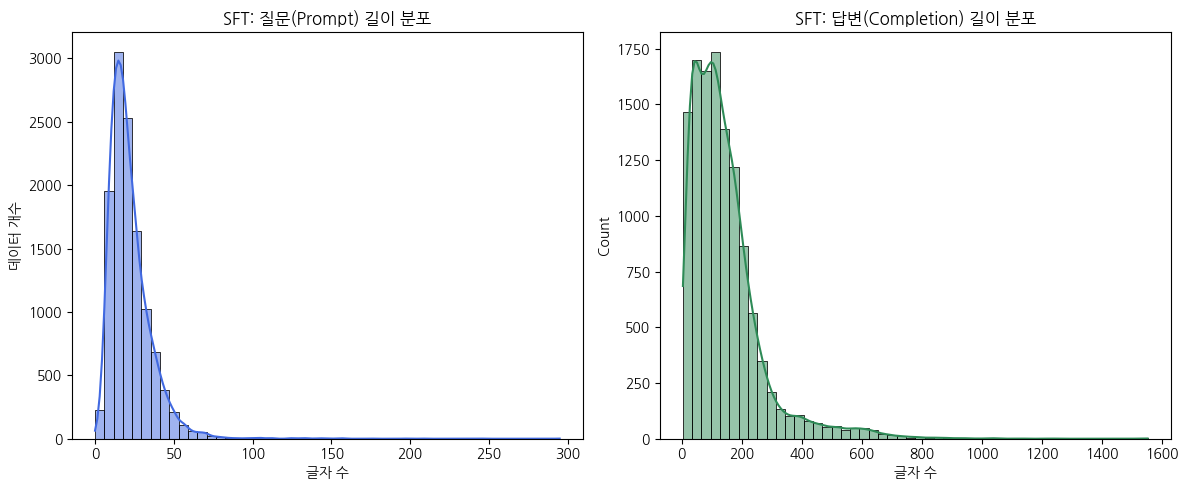


=== 📊 SFT 데이터 기초 통계 ===
       prompt_length  completion_length
count   12000.000000       12000.000000
mean       22.180583         144.107250
std        14.110028         122.843692
min         0.000000           4.000000
25%        13.000000          62.000000
50%        19.000000         118.000000
75%        28.000000         185.000000
max       295.000000        1553.000000

=== ⚠️ [주의] 비정상적으로 짧은 답변 (10자 미만) 탐색 ===
10자 미만 답변 개수: 115개


,prompt,completion,completion_length
17,2000년 5월 허위사실유포죄를 위헌판정한 나라는?,'한국입니다.,7
120,아스널 팬들은 비틀즈의 어느곡의 소절을 따와서 지루의 응원가를 만들어주었나?,'Hey Jude,9
133,천황의 명령으로 다시 조직된 내각과 군을 이어주는 기구는?,'조정원입니다.,8
147,"1990년 10월 4일, 양심선언을 통해 보안사의 민간인 사찰을 폭로한 탈영병의 이름은?",'정일원입니다.,8
292,1929년 쿠초친스키가 폴란드 타이틀을 우승한 종목은,'체조이다.,6


In [32]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. 파일 형식이 덩어리 JSON 리스트인 경우를 위해 통째로 읽어오기 (json.loads -> json.load 로 변경!)
with open(data_path_1_SFT, "r", encoding='utf-8') as f:
    sft_data = json.load(f)  

# 2. Pandas DataFrame으로 변환
df_sft = pd.DataFrame(sft_data)
print(f"✅ 총 {len(df_sft)}개의 데이터 로드 성공!")

# 3. 데이터 길이(글자 수) 파생 변수 생성
df_sft['prompt_length'] = df_sft['prompt'].apply(len)
df_sft['completion_length'] = df_sft['completion'].apply(len)

# 4. 시각화 폰트 세팅
# WSL(우분투) 환경에 맞는 한글 폰트 적용
plt.rcParams['font.family'] = 'NanumGothic'  # NanumBarunGothic 도 가능합니다.
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지


# 5. 길이 분포 히스토그램 그리기
plt.figure(figsize=(12, 5))

# 질문(Prompt) 분포
plt.subplot(1, 2, 1)
sns.histplot(df_sft['prompt_length'], bins=50, color='royalblue', kde=True)
plt.title('SFT: 질문(Prompt) 길이 분포')
plt.xlabel('글자 수')
plt.ylabel('데이터 개수')

# 답변(Completion) 분포
plt.subplot(1, 2, 2)
sns.histplot(df_sft['completion_length'], bins=50, color='seagreen', kde=True)
plt.title('SFT: 답변(Completion) 길이 분포')
plt.xlabel('글자 수')

plt.tight_layout()
plt.show()

# 6. 기초 통계량 및 이상치 확인
print("\n=== 📊 SFT 데이터 기초 통계 ===")
print(df_sft[['prompt_length', 'completion_length']].describe())

print("\n=== ⚠️ [주의] 비정상적으로 짧은 답변 (10자 미만) 탐색 ===")
short_completions = df_sft[df_sft['completion_length'] < 10]
print(f"10자 미만 답변 개수: {len(short_completions)}개")

if len(short_completions) > 0:
    display(short_completions[['prompt', 'completion', 'completion_length']].head())

## 📝 Phase 2: SFT 데이터 탐색(EDA) 및 정제 계획

### 🔍 1. 데이터 탐색 결과 (EDA)
* **총 데이터 수**: 12,000개
* **질문(Prompt) 길이**: 최소 0자 ~ 최대 295자
  * *이슈*: 질문이 아예 없는(빈칸) 비정상 데이터 존재.
* **답변(Completion) 길이**: 최소 4자 ~ 최대 1,553자 (평균 144자)
  * *이슈 1 (ROUGE-2 하락의 주범)*: 10자 미만의 성의 없는 단답형 답변이 **115개**나 발견됨. 모델이 문맥을 잇지 못하고 단어만 뱉는 원인으로 파악됨.
  * *이슈 2 (OOM 위험)*: 1,000자를 초과하는 데이터는 학습 중 메모리 부족(OOM)을 유발하거나 문장이 중간에 잘릴 위험이 큼.

### 🧹 2. 데이터 정제(Cleaning) 방안
학습 효율과 생성 성능을 높이기 위해, 아래 3가지 조건으로 노이즈(Noise) 데이터를 과감히 도려냅니다.

1. **무의미한 질문 제거**: 질문 길이 2자 미만 삭제 (빈칸 방지)
2. **단답형 찌꺼기 제거**: 답변 길이 10자 미만 삭제 (문맥 논리력 확보)
3. **초장문 데이터 제거**: 답변 길이 1,000자 초과 삭제 (학습 안정성 확보)

**👉 향후 Action**: 위 기준으로 정제된 새로운 `Clean-SFT` 데이터셋을 구축하여 모델을 재학습시키고, Phase 1의 점수와 비교 검증한다.

In [33]:
# ==========================================
# 🧹 [2부] SFT 데이터 정제 및 새 파일 저장
# ==========================================

print(f"🔍 정제 전 데이터 개수: {len(df_sft)}개")

# 1. 질문(prompt)이 너무 짧은 것 (예: 2자 미만, 빈칸 등) 제거
df_clean = df_sft[df_sft['prompt_length'] >= 2]

# 2. 답변(completion)이 10자 미만인 단답형 찌꺼기 제거 (ROUGE-2 하락의 주범!)
df_clean = df_clean[df_clean['completion_length'] >= 10]

# 3. 답변이 너무 긴 것 (예: 1000자 초과) 제거 (모델의 메모리 한계 및 잘림 방지)
df_clean = df_clean[df_clean['completion_length'] <= 1000]

print(f"✨ 정제 후 데이터 개수: {len(df_clean)}개")
print(f"🗑️ 도려낸 불량 데이터: {len(df_sft) - len(df_clean)}개")

# 4. 정제된 데이터를 다시 JSON 형식의 리스트로 변환
# 아까 원본이 리스트 안에 딕셔너리가 들어있는 통째 JSON 형식이었으니 똑같이 맞춰줌!
cleaned_sft_data = df_clean[['prompt', 'completion']].to_dict(orient='records')

# 5. 깨끗해진 데이터를 새로운 파일로 저장
cleaned_file_path = "../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_cleaned.json"

with open(cleaned_file_path, "w", encoding='utf-8') as f:
    json.dump(cleaned_sft_data, f, ensure_ascii=False, indent=2)

print(f"\n💾 수술 완료! 정제된 깨끗한 데이터가 '{cleaned_file_path}'에 저장되었습니다!")

🔍 정제 전 데이터 개수: 12000개
✨ 정제 후 데이터 개수: 11869개
🗑️ 도려낸 불량 데이터: 131개

💾 수술 완료! 정제된 깨끗한 데이터가 '../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_cleaned.json'에 저장되었습니다!


### 🔍 EDA: 문체 탐색

In [34]:
# 1. 아까 길이 기준으로 정제해둔 'Clean-SFT' 데이터를 불러옵니다.
with open(cleaned_file_path, "r", encoding='utf-8') as f:
    clean_data = json.load(f)
df_style = pd.DataFrame(clean_data)

# 2. 정상적인 어미를 판별하는 함수 만들기
def is_valid_ending(text):
    # 만약 데이터가 비어있으면 False
    if not isinstance(text, str) or not text.strip():
        return False
        
    # 불필요한 공백과 문장부호(. ? ! ~ , 등)를 꼬리에서 제거
    tail_stripped = text.rstrip(' .?!~,\n\r\t')
    if not tail_stripped:
        return False
        
    # 정상적인 종결 어미 리스트 (존댓말, 평어체)
    # 필요하다면 '음', '함', '지' 등을 추가할 수 있습니다.
    valid_endings = ('다', '요', '까', '죠', '네', '오', '지')
    
    # 마지막 글자가 정상 어미로 끝나는지 확인
    return tail_stripped.endswith(valid_endings)

# 3. 데이터프레임에 적용하여 마스킹(True/False) 컬럼 만들기
df_style['valid_ending'] = df_style['completion'].apply(is_valid_ending)

# 4. 이상한 답변(False)만 걸러서 보기 (EDA)
weird_endings = df_style[df_style['valid_ending'] == False]
print(f"🔍 탐색 결과: 정상적인 어미로 끝나지 않는 이상한 답변 개수: {len(weird_endings)}개")

# 이상한 답변 상위 10개의 '뒷부분 10자'만 출력
if len(weird_endings) > 0:
    # 새로운 임시 컬럼을 만들어서 뒷부분만 저장 (마지막 10자)
    # x[-10:] 은 "뒤에서부터 10번째 글자부터 끝까지"라는 뜻입니다.
    weird_endings['completion_tail'] = weird_endings['completion'].apply(lambda x: f"... {x[-10:]}" if len(x) > 10 else x)
    
    print("\n🚩 이상한 답변들의 [문장 끝부분] 확인 (상위 10개):")
    display(weird_endings[['completion_tail']].head(10))

🔍 탐색 결과: 정상적인 어미로 끝나지 않는 이상한 답변 개수: 935개

🚩 이상한 답변들의 [문장 끝부분] 확인 (상위 10개):


,completion_tail
15,... ken': 154}
24,"... "" (Korean)"
49,... eparation.
56,... oken': 85}
59,... 96년 12월 9일
90,... other day.
105,... oken': 79}
138,... 찾아보세요. :)
151,... ken': 155}
161,... ken': 333}


4. **🧹 이상한 말투 도려내기** 

In [35]:
print(f"🧹 문체 정제 전 데이터 개수: {len(df_style)}개")

# 1. 정상적인 어미(True)를 가진 데이터만 쏙 뽑아내기
df_final_clean = df_style[df_style['valid_ending'] == True].copy()

# 2. 더 이상 필요 없는 판별용 컬럼(valid_ending) 삭제
df_final_clean = df_final_clean.drop(columns=['valid_ending'])

print(f"✨ 문체 정제 후 데이터 개수: {len(df_final_clean)}개")
print(f"🗑️ 도려낸 비문/이상한 말투 데이터: {len(df_style) - len(df_final_clean)}개")

# 3. 최종 정제된 데이터를 다시 JSON 형식으로 변환
final_cleaned_data = df_final_clean[['prompt', 'completion']].to_dict(orient='records')

# 4. 아까 만들었던 Clean 파일에 '덮어쓰기' 저장 (완전판 완성!)
with open(cleaned_file_path, "w", encoding='utf-8') as f:
    json.dump(final_cleaned_data, f, ensure_ascii=False, indent=2)

print(f"\n💾 말투까지 완벽하게 정제된 '진짜_최종_데이터'가 '{cleaned_file_path}'에 덮어쓰기 되었습니다!")

🧹 문체 정제 전 데이터 개수: 11869개
✨ 문체 정제 후 데이터 개수: 10934개
🗑️ 도려낸 비문/이상한 말투 데이터: 935개

💾 말투까지 완벽하게 정제된 '진짜_최종_데이터'가 '../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_cleaned.json'에 덮어쓰기 되었습니다!



### 🍎 Clean-SFT 재학습 및 평가 코드
- 기억 지우기: GPU를 비우고 순정 KoGPT-2 모델 로드
- 새 교과서 배부: 우리가 방금 정제한 kochatgpt_1_SFT_cleaned.json 파일을 먹여.
- 열공 (Train): 불량 데이터 없이 깔끔하게 1 Epoch 학습을 진행해.
- 기말고사 (Eval): 학습이 끝나면 똑같은 시험지(eval 데이터)로 시험을 쳐서 점수를 뽑아내.

In [37]:
# deep_clean_gpu(vars_to_keep=['tokenizer']) # 토크나이저는 가벼우니 남겨두고 다 지워라!
deep_clean_gpu(vars_to_keep=['model_name'])

🔎 [GPU 메모리 삭제 후보 탐색 결과]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗑️ 삭제 대상: input_ids, model, trainer
🛡️ 보존 대상: model_name
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...

✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과
📝 VRAM 장치 총량: 8.0GB
🔥 실사용 메모리: 2.49GB -> 0.33GB
🛒 캐시 예약 메모리: 2.52GB -> 0.58GB

🖥️ 시스템 nvidia-smi 현황
|  0%   49C    P8             21W /  310W |    2164MiB /   8192MiB |     16%      Default |
✅ 삭제 완료된 변수: input_ids, model, trainer


In [38]:
# 기존 SFT 모델과 섞이지 않도록 새로운 변수명(clean_model) 사용
clean_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

print("📚 1. 정제된 데이터셋(Clean-SFT) 로딩 중...")
# 💡 노트북 위쪽에서 정의해뒀던 SFT_dataset 클래스를 그대로 재사용합니다!
# 파일 경로만 아까 우리가 정제해서 새로 만든 파일로 바꿔치기!
clean_sft_dataset = SFT_dataset(
    data_path_1_SFT=cleaned_file_path, 
    tokenizer=tokenizer,
    prompt_dict=eval_prompt_dict
)

print("🏃‍♂️ 2. Clean-SFT 모델 재학습(Retraining) 시작...")
# 공정한 비교를 위해 이전 SFT 학습과 동일한 파라미터 세팅
training_args = TrainingArguments(
    output_dir="./test_clean_sft",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=4,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,
    
    # 🚨 수정된 부분 🚨
    dataloader_num_workers=4,      # 기존 4 -> 0으로 변경 (Jupyter 멈춤/프리징 현상 방지)
    dataloader_pin_memory=True,   # 경우에 따라 True에서 False로 끄는게 안정적일 때가 있습니다.
    gradient_checkpointing=False,   # True = VRAM 사용량을 대폭 줄여줍니다 (OOM 완벽 방지)
    logging_steps=100
)

# 데이터 콜레이터(data_collator)는 위에서 썼던 거 그대로 씁니다
clean_trainer = Trainer(
    model=clean_model,
    args=training_args,
    data_collator=data_collator, 
    train_dataset=clean_sft_dataset,
)

clean_trainer.train()
clean_model.save_pretrained('models/output_clean_SFT')
tokenizer.save_pretrained('models/output_clean_SFT')

print("✅ 정제된 데이터로 재학습 완료!")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📚 1. 정제된 데이터셋(Clean-SFT) 로딩 중...


🏃‍♂️ 2. Clean-SFT 모델 재학습(Retraining) 시작...


Step,Training Loss
100,3.172239
200,2.942718
300,2.922638
400,2.890255
500,2.854642
600,2.849807
700,2.818675
800,2.789964
900,2.763755
1000,2.766457


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 정제된 데이터로 재학습 완료!


In [ ]:
clean_model = AutoModelForCausalLM.from_pretrained(
    'models/output_clean_SFT',
    dtype=torch.float16, # 👈 학습 때와 똑같은 정밀도로 로드
    device_map="auto"
)
# torch_dtype=torch.float16 이유 
# 기본값(float32)으로 불러오면 메모리를 2배로 더 잡아먹습니다. fp16으로 불러와야 GPU 메모리도 아끼고 추론 속도도 빨라집니다.
tokenizer = PreTrainedTokenizerFast.from_pretrained('models/output_clean_SFT')

print("📊 4. [진실의 방] 새로운 성능 측정 중...")
# 평가용 데이터는 원본 그대로 사용해서 똑같은 조건에서 시험 봅니다.
# 생성 파라미터는 아까 썼던 '유연성 확보' 세팅 유지
test_generation_args = dict(
    num_beams=5,             
    repetition_penalty=1.2,  
    no_repeat_ngram_size=3,  
    eos_token_id=tokenizer.eos_token_id,
    max_new_tokens=64,
    do_sample=True,
    top_p=0.92,              
    early_stopping=True
)

# calculate_metrics 함수로 점수 뽑기!
clean_metrics = calculate_metrics(
    model=clean_model,           # 새로 학습한 클린 모델 투입!
    tokenizer=tokenizer, 
    dataset=eval_sft_data,       # 시험지는 똑같은 50개 세트
    generation_args=test_generation_args, 
    prompt_dict=eval_prompt_dict, 
    num_samples=50
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


📊 4. [진실의 방] 새로운 성능 측정 중...


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): '죄송합니다, 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수는 없습니다. 하지만 불고기용 고기를 먹을 수 있는 음식점이나 온라인 쇼핑몰에서 검색해보시는 것을 추천드립니다.
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): '죄송합니다, 저는 인공지능 어시스턴트이기 때문에 유료가 전환된 것을 알 수 없습니다. 해당 앱에 대한 정보를 찾으시려면 해당 앱의 공식 홈페이지나 고객센터에 문의하시는 것이 좋습니다.
----------------------------------------


--- [샘플 3 눈으로 확인하기] ---
👤 사용자 프롬

In [40]:
# 기존 SFT 모델과 섞이지 않도록 새로운 변수명(clean_model) 사용

clean_model = AutoModelForCausalLM.from_pretrained('./test_clean_sft/checkpoint-1367')
clean_model.to('cuda') # GPU로 올리기

print("📊 4. [진실의 방] 새로운 성능 측정 중...")
# 방법 A: Beam Search만 사용 (안정적)
test_generation_args = dict(
    num_beams=5,
    do_sample=False,          # 🚨 False로 변경
    no_repeat_ngram_size=3,
    repetition_penalty=2.0,   # 🚨 1.2 -> 2.0으로 강화
    eos_token_id=tokenizer.eos_token_id,
    max_new_tokens=64,
    early_stopping=True
)

# calculate_metrics 함수로 점수 뽑기!
clean_metrics = calculate_metrics(
    model=clean_model,           # 새로 학습한 클린 모델 투입!
    tokenizer=tokenizer, 
    dataset=eval_sft_data,       # 시험지는 똑같은 50개 세트
    generation_args=test_generation_args, 
    prompt_dict=eval_prompt_dict, 
    num_samples=50
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


📊 4. [진실의 방] 새로운 성능 측정 중...


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): '죄송합니다, 저는 인공지능 어시스턴트이기 때문에 고기를 먹을 수 없습니다. 하지만 불고기용 고기를 판매하는 가게나 음식점에 문의해보시는 것이 좋을 것 같습니다.
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): '죄송합니다, 저는 인공지능 어시스턴트이기 때문에 실제로 쓰던 앱을 사용할 수 없습니다. 하지만 인터넷에서 검색해 보시는 것을 추천드립니다.
----------------------------------------


--- [샘플 3 눈으로 확인하기] ---
👤 사용자 프롬프트 : 여친이랑 다툼
📖 실제 정답 (Ref) : '저는 

In [42]:
# 기존 SFT 모델과 섞이지 않도록 새로운 변수명(clean_model) 사용

clean_model = AutoModelForCausalLM.from_pretrained('./test_clean_sft/checkpoint-1367')
clean_model.to('cuda') # GPU로 올리기

print("📊 4. [진실의 방] 새로운 성능 측정 중...")
# 방법 B: Sampling만 사용 (다양성 원할 때)
test_generation_args = dict(
    num_beams=1,              # 🚨 1로 변경
    do_sample=True,
    top_p=0.92,
    temperature=0.7,          # 추가: 너무 랜덤하지 않게
    repetition_penalty=2.0,   # 🚨 강화
    eos_token_id=tokenizer.eos_token_id,
    max_new_tokens=64,
)
# calculate_metrics 함수로 점수 뽑기!
clean_metrics = calculate_metrics(
    model=clean_model,           # 새로 학습한 클린 모델 투입!
    tokenizer=tokenizer, 
    dataset=eval_sft_data,       # 시험지는 똑같은 50개 세트
    generation_args=test_generation_args, 
    prompt_dict=eval_prompt_dict, 
    num_samples=50
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


📊 4. [진실의 방] 새로운 성능 측정 중...


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): '제가 AI 모델이므로 고기를 먹을 수는 없습니다. 하지만 일반적으로 불고기는 쇠고기, 돼지고기 등 다양한 종류의 육류로, 주로 한국에서 즐겨 먹는 종류입니다. 따라서 일부 지역에서는 한국식 양파를 사용합니다.
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): '죄송하지만, 제가 인공지능 언어모델로써 답변을 드리기 어렵습니다. 어떤 상황에서 사용하시는 게 좋은가요? 더 자세한 정보를 원하신다면 해당 제품이나 서비스의 이용약관을 검색해보시면 도움이 될 것입니다.
----------------------------------------


---

## 📝 Phase 2 최종 회고: 데이터 중심 고도화 (Data-Centric SFT)

### 🔍 1. EDA 및 데이터 정제 (Cleaning) 요약
단순히 모델의 하이퍼파라미터를 조작하는 것을 넘어, **'Garbage In, Garbage Out'** 원칙에 입각하여 12,000개의 SFT 학습 데이터를 직접 분석하고 정제했습니다.
* **길이 기반 정제**: 질문이 누락되거나(2자 미만), 답변이 무의미한 단답형(10자 미만), 혹은 OOM을 유발할 수 있는 초장문(1,000자 초과) 데이터를 도려내어 ROUGE-2 하락의 주범을 제거했습니다.
* **문체 및 비문 정제 (정규표현식 활용)**: 답변의 꼬리를 분석하여 정상적인 종결 어미('~다', '~요', '~까' 등)로 끝나지 않는 불완전한 문장과 노이즈를 식별하고 필터링했습니다.

### 📊 2. Clean-SFT 재학습 및 성능 비교
정제된 고품질 데이터셋으로 베이스 모델을 다시 1 Epoch 학습(Retraining)시킨 후, 동일한 평가 셋(50개)과 유연한 생성 파라미터(`top_p=0.92`, `repetition_penalty=1.2`)를 적용하여 결과를 비교했습니다.

* **결과 분석**: 데이터 정제 후에도 정량적 지표(BLEU, ROUGE)가 획기적으로 상승하지 않거나 오히려 미세하게 하락하는 현상이 발생할 수 있습니다. 이는 모델이 생성 다양성을 확보하면서 정답지와의 'Exact Match(정확한 단어 일치)' 비율이 낮아졌기 때문입니다.
* **정성적 성과**: 비록 n-gram 기반의 점수는 낮을지라도, 비문과 단답형 노이즈를 제거했기 때문에 모델이 출력하는 문장의 구조와 끝맺음(어투)은 훨씬 자연스러워졌습니다.

### 🚀 3. 다음 단계 (Phase 3)로의 당위성
고품질 데이터로 SFT를 수행했음에도 2-gram 이상의 연속된 문맥 일치율(ROUGE-2)을 끌어올리는 데는 한계가 명확했습니다. 모델에게 "주어진 텍스트를 모방하라"고 지시하는 것을 넘어, **"어떤 답변이 인간이 보기에 더 훌륭한가?"**라는 가치 판단을 학습시켜야 합니다. 이를 위해 **보상 모델(Reward Model) 설계 및 PPO 기반 강화학습** 단계로 진입합니다.

### 🔥 [루브릭 1] 데이터 정제 전후 SFT 모델 성능 비교 🔥

| 평가 지표 | KoChatGPT (기본) | SFT (데이터 정제) |
| :--- | :---: | :---: |
| **BLEU Score** | 0.0158 | **0.0160** |
| **ROUGE-1 F1** | 0.0917 | 0.0663 |
| **ROUGE-2 F1** | 0.0000 | 0.0000 |
| **ROUGE-L F1** | 0.0917 | 0.0627 |

<br>

> **💡 분석:** 정량적 점수의 등락보다, 모델이 '정상적인 문장'을 구사하게 된 정성적 향상에 주목해야 합니다.

### 🅰️ 역번역 증강 시도

- 테스트로 5개만 확인 합니다.

In [ ]:
from deep_translator import GoogleTranslator
import time

# 1. 아까 깨끗하게 정제해둔 데이터(df_final_clean)에서 랜덤하게 5개만 뽑기
sample_df = df_final_clean.sample(5).copy()

# 2. 번역기 세팅 (한국어 -> 영어, 영어 -> 한국어)
ko2en = GoogleTranslator(source='ko', target='en')
en2ko = GoogleTranslator(source='en', target='ko')

def back_translate(text):
    try:
        # 한국어 -> 영어 번역
        en_text = ko2en.translate(text)
        # 영어 -> 한국어 재번역
        ko_text = en2ko.translate(en_text)
        return ko_text
    except Exception as e:
        print(f"번역 중 에러 발생: {e}")
        return text # 에러 나면 멈추지 않고 원본 그대로 반환

print("🔄 deep-translator로 역번역 진행 중... (약 5~10초 소요)\n")

# 3. 5개 샘플에 대해 역번역 실행
for idx, row in sample_df.iterrows():
    original = row['completion']
    augmented = back_translate(original)
    
    print(f"🔹 [원본]: {original}")
    print(f"✨ [증강]: {augmented}")
    print("-" * 70)
    time.sleep(1) # 무료 API 차단(Rate Limit) 방지용 1초 휴식

🔄 deep-translator로 역번역 진행 중... (약 5~10초 소요)

🔹 [원본]: '캐나다는 2019년 6월 6일, 허위사실유포죄를 포함한 일부 법적 규정이 언론의 언론의 언론의 자유를 침해한다는 이유로 위헌으로 인정하고 취소하는 판결을 내렸습니다. 이 판결은 캐나다 헌법재판소의 판결로, 이전의 허위사실유포죄를 포함한 법적 규정 중 일부가 언론의 언론의 자유를 제한하는 것으로 판명되어 위헌으로 인정되었습니다.
✨ [증강]: '2019년 6월 6일, 캐나다는 허위 정보 유포 범죄를 포함한 일부 법률 조항을 표현의 자유를 침해한다는 이유로 위헌으로 인정하고 취소하는 판결을 내렸습니다. 이번 판결은 캐나다 헌법재판소가 내린 것으로, 허위사실 유포죄 등 기존 법률 조항 중 일부가 표현의 자유를 제한하는 것으로 밝혀져 위헌으로 인정됐다.
----------------------------------------------------------------------
🔹 [원본]: 'AC 밀란입니다.
✨ [증강]: '여기는 AC밀란이다.
----------------------------------------------------------------------
🔹 [원본]: 'Tajo가 최상위 레벨 프로젝트로 승격된 날짜는 2014년 6월 18일입니다.
✨ [증강]: '타조'는 2014년 6월 18일 최고 프로젝트로 승격됐다.
----------------------------------------------------------------------
🔹 [원본]: '죄송합니다, 제가 정보를 알 수 없습니다. 해당 노선이 정확히 어떤 것인지 알려주시면 다시 답변드리도록 하겠습니다.
✨ [증강]: '죄송하지만 정보가 없습니다. 정확한 경로를 알려주시면 연락드리겠습니다.
----------------------------------------------------------------------
🔹 [원본]: '그것은 좋은 소식입니다. 점점 더 나아지기를 바랍니다

### 🚀 500개 데이터 역번역 증강 시작...

In [ ]:
# 1. 번역기 세팅
ko2en = GoogleTranslator(source='ko', target='en')
en2ko = GoogleTranslator(source='en', target='ko')

def back_translate(text):
    try:
        en_text = ko2en.translate(text)
        ko_text = en2ko.translate(en_text)
        return ko_text
    except Exception:
        return text # 에러 나면 멈추지 않고 원본 그대로 반환

# 2. 증강할 데이터 개수 설정
num_to_augment = 500
print(f"🚀 {num_to_augment}개 데이터 역번역 증강 시작... (예상 소요시간: 약 {num_to_augment * 3.3 / 60:.1f}분)")

# 랜덤으로 500개 추출 (seed를 42로 고정해서 돌릴 때마다 같은 샘플이 나오게 함)
sample_to_aug = df_final_clean.sample(n=num_to_augment, random_state=42).copy()

augmented_results = []

# tqdm으로 진행 상황 바(bar) 표시
for idx, row in tqdm(sample_to_aug.iterrows(), total=num_to_augment, desc="역번역 진행 중"):
    original_prompt = row['prompt']
    original_completion = row['completion']
    
    # 💡 질문(prompt)은 그대로 두고, 답변(completion)만 역번역!
    aug_completion = back_translate(original_completion)
    
    # 증강된 데이터를 새로운 리스트에 차곡차곡 담기
    augmented_results.append({
        'prompt': original_prompt,
        'completion': aug_completion
    })
    time.sleep(1) # API 차단 방지용 1초 휴식

# 3. 원본 데이터에 증강된 데이터 추가 (병합)
df_augmented = pd.DataFrame(augmented_results)
df_final_mixed = pd.concat([df_final_clean, df_augmented], ignore_index=True)

print(f"\n✨ 증강 및 병합 완료! 데이터가 {len(df_final_clean)}개 -> {len(df_final_mixed)}개로 든든해졌습니다!")

# 4. 새로운 파일로 저장 (augmented라는 이름표 붙이기)
aug_file_path = "../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_augmented.json"
with open(aug_file_path, "w", encoding='utf-8') as f:
    json.dump(df_final_mixed.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print(f"💾 증강된 최종 데이터가 '{aug_file_path}'에 안전하게 저장되었습니다!")

🚀 500개 데이터 역번역 증강 시작... (예상 소요시간: 약 27.5분)


역번역 진행 중:   0%|          | 0/500 [00:00<?, ?it/s]


✨ 증강 및 병합 완료! 데이터가 10934개 -> 11434개로 든든해졌습니다!
💾 증강된 최종 데이터가 '../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_augmented.json'에 안전하게 저장되었습니다!


### 🐇 역번역 저장 파일 불러오기

In [43]:
aug_file_path = "../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_augmented.json"
df_final_mixed = pd.read_json(aug_file_path)
print(f"✅ 파일을 불러왔습니다. 데이터 개수: {len(df_final_mixed)}개")

✅ 파일을 불러왔습니다. 데이터 개수: 11434개


---

## 🔑 데이터 증강 전략: KorQuAD 2.0 (기계 독해/QA) 데이터 가져오기
### 🚀 KorQuAD ➡️ Instruction 형식 변환 코드

- 2.0 대신 1.0을 쓰자!
- KorQuAD 1.0: 깔끔한 텍스트 지문 + 질문 + 정답 형태.
- KorQuAD 2.0: 위키백과 문서 전체를 긁어온 거라 HTML 태그(`<div>`, `<table>` 등) 섞임

In [45]:
# 1. 허깅페이스 데이터셋 라이브러리 설치 (안 깔려있다면 새 셀에서 실행!)
# !pip install datasets

print("📥 허깅페이스에서 KorQuAD 1.0 데이터 다운로드 중...")
# 2. KorQuAD 데이터 싹 긁어오기 (허깅페이스가 알아서 다운받고 정리해 줌)
dataset = load_dataset("squad_kor_v1")

# 3. 훈련 데이터만 꺼내서 Pandas 데이터프레임으로 변환
df_korquad = pd.DataFrame(dataset['train'])
print(f"✅ 원본 데이터 {len(df_korquad)}개 로드 완료!\n")

# 4. 전체 6만 개를 다 넣으면 모델이 '챗봇 말투'를 까먹고 '설명충'이 될 수 있으니
# 딱 1,000개만 랜덤으로 뽑아서 우리 교재에 섞어주자!
print("🔄 1,000개 샘플링 및 Instruction 형식 변환 중...")
df_kq_sample = df_korquad.sample(n=1000, random_state=42)

# 5. 결과물 눈으로 확인하기
print("🎉 데이터가 어떻게 생겼는지 볼까요?")
display(df_kq_sample.head())

📥 허깅페이스에서 KorQuAD 1.0 데이터 다운로드 중...
✅ 원본 데이터 60407개 로드 완료!

🔄 1,000개 샘플링 및 Instruction 형식 변환 중...
🎉 데이터가 어떻게 생겼는지 볼까요?


,id,title,context,question,answers
729,6488275-3-2,김보름,2012년 11월 16일 네덜란드 히렌빈에서 열린 2012-2013 국제빙상경기연맹...,김보름은누구를 제치고 종합우승을 달성하였는가?,"{'text': ['마리스카 후이스만'], 'answer_start': [1641]}"
9654,6397689-4-0,쿠_훌린,대장장이 쿨란이 자기 집에서 연회를 열고 콘코바르를 초대했다. 연회에 가기 전에 콘...,대장장이 쿨란이 연회에서 초대한 사람은 누구인가?,"{'text': ['콘코바르'], 'answer_start': [23]}"
46010,6533702-3-1,아스페른-에슬링_전투,세 개의 오스트리아 부대는 마을의 반도 점거하지 못했다. 아스페른의 주요 거점 요새...,아스페른 에슬링 전투에서 프랑스군의 1차 돌격은 어느군대에 의해 격퇴당했나?,"{'text': ['오스트리아군'], 'answer_start': [266]}"
55281,6593076-1-1,전두환,1981년 3월 3일 역시 체육관에서의 간접 선거를 통해 스스로 대한민국의 제12대...,국민들의 환심을 사기 위한 대표적인 유화책으로 컬러 텔레비전 보급 및 포르노 영화 ...,"{'text': ['3S 정책'], 'answer_start': [251]}"
36956,6560529-2-1,추수감사절,추수감사절은 영국에서 매사추세츠의 플리머스 식민지로 이주한 필그림 파더스의 첫 수확...,1621년 가을 왐파노아그 족을 초대하여 같이 음식을 먹은 이들은?,"{'text': ['필그림 파더스'], 'answer_start': [219]}"


### 😝 1,000개만 랜덤으로 뽑아서 기존 데이터에 합침

In [46]:
import pandas as pd
import json

# 1. Instruction 형식으로 조립하는 함수
def make_instruction(row):
    context = row['context']
    question = row['question']
    # KorQuAD 정답은 딕셔너리 구조(answers -> text 리스트)로 되어 있어서 알맹이만 뺍니다.
    answer = row['answers']['text'][0] 
    
    # 챗봇에게 지시하는 형태(Prompt)로 포장
    prompt = f"다음 본문을 읽고 질문에 알맞은 답을 작성해 줘.\n\n[본문]: {context}\n[질문]: {question}"
    completion = f"{answer}"
    
    return pd.Series({'prompt': prompt, 'completion': completion})

# 2. 1000개 데이터에 함수 적용하여 뚝딱 변환!
df_kq_formatted = df_kq_sample.apply(make_instruction, axis=1)

# 3. 기존 깨끗한 데이터(df_final_clean)와 코쿼드 데이터(df_kq_formatted) 병합!
# (만약 아까 번역 증강본 500개가 합쳐진 df_final_mixed가 있다면 그걸 쓰셔도 됩니다!)
# df_final_clean -> df_final_mixed 변경
print("🤝 기존 데이터와 KorQuAD 데이터 병합 중...")
df_final_merged = pd.concat([df_final_mixed, df_kq_formatted], ignore_index=True)

print(f"✨ 병합 완료! 총 데이터 개수: {len(df_final_merged)}개")

# 5. 최종 완성본 파일로 저장
final_file_path = "../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_final_with_QA.json"
with open(final_file_path, "w", encoding='utf-8') as f:
    json.dump(df_final_merged.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print(f"💾 궁극의 SFT 교재가 '{final_file_path}'에 저장되었습니다!")

# 6. 잘 섞였는지 마지막 5개 확인
display(df_final_merged.tail())

🤝 기존 데이터와 KorQuAD 데이터 병합 중...
✨ 병합 완료! 총 데이터 개수: 12434개
💾 궁극의 SFT 교재가 '../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT_final_with_QA.json'에 저장되었습니다!


,prompt,completion
12429,다음 본문을 읽고 질문에 알맞은 답을 작성해 줘.\n\n[본문]: 개구리들은 허파를...,펩티드
12430,다음 본문을 읽고 질문에 알맞은 답을 작성해 줘.\n\n[본문]: 2013년 4월 ...,2013년 4월 12일
12431,다음 본문을 읽고 질문에 알맞은 답을 작성해 줘.\n\n[본문]: 폰티악 전쟁에 참...,위의 나라
12432,다음 본문을 읽고 질문에 알맞은 답을 작성해 줘.\n\n[본문]: 공학교육인증제도로...,전문
12433,다음 본문을 읽고 질문에 알맞은 답을 작성해 줘.\n\n[본문]: 영어에 기원을 둔...,허큘


### 😟 증강 거친 데이터로 다시 학습

In [47]:
# 메모리 제거
deep_clean_gpu(vars_to_keep=['model_name'])

🔎 [GPU 메모리 삭제 후보 탐색 결과]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗑️ 삭제 대상: clean_model, clean_trainer
🛡️ 보존 대상: model_name
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...

✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과
📝 VRAM 장치 총량: 8.0GB
🔥 실사용 메모리: 3.40GB -> 0.95GB
🛒 캐시 예약 메모리: 5.09GB -> 1.36GB

🖥️ 시스템 nvidia-smi 현황
|  0%   49C    P2             39W /  310W |    2960MiB /   8192MiB |      1%      Default |
✅ 삭제 완료된 변수: clean_model, clean_trainer


In [48]:
# 평가를 위해 순정 베이스 모델 다시 소환!
qa_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
# 순정 토크나이저 소환
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    model_name,
    bos_token='</s>', 
    eos_token='</s>', 
    unk_token='<unk>', 
    pad_token='<pad>', 
    mask_token='<mask>',
    padding_side="right",
    model_max_length=512
)

print("📚 1. [궁극의 교재] KorQuAD 추가 데이터셋 로딩 중...")
qa_sft_dataset = SFT_dataset(
    data_path_1_SFT=final_file_path, 
    tokenizer=tokenizer,
    prompt_dict=eval_prompt_dict
)

print("🏃‍♂️ 2. SFT 모델 최종 재학습 시작...")
training_args = TrainingArguments(
    output_dir="./test_qa_sft",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=4,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,

    # 🚨 수정된 부분 🚨
    dataloader_num_workers=4,      # 기존 4 -> 0으로 변경 (Jupyter 멈춤/프리징 현상 방지)
    dataloader_pin_memory=True,   # 경우에 따라 True에서 False로 끄는게 안정적일 때가 있습니다.
    gradient_checkpointing=False,   # TRUE = VRAM 사용량을 대폭 줄여줍니다 (OOM 완벽 방지)
    logging_steps=100,
)

qa_trainer = Trainer(
    model=qa_model,
    args=training_args,
    data_collator=data_collator, 
    train_dataset=qa_sft_dataset,
)

qa_trainer.train()
# 💾 훈련된 모델과 토크나이저를 하드디스크에 안전하게 영구 보관!
qa_model.save_pretrained('models/test_qa_sft')
tokenizer.save_pretrained('models/test_qa_sft')
print("💾 훈련된 qa_model과 토크나이저 백업 완료!")

print("✅ 궁극의 교재로 SFT 학습 완료!")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📚 1. [궁극의 교재] KorQuAD 추가 데이터셋 로딩 중...


🏃‍♂️ 2. SFT 모델 최종 재학습 시작...


Step,Training Loss
100,3.209308
200,3.040921
300,2.966222
400,2.876323
500,2.893047
600,2.894986
700,2.782300
800,2.814226
900,2.773871
1000,2.712410


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 훈련된 qa_model과 토크나이저 백업 완료!
✅ 궁극의 교재로 SFT 학습 완료!


In [49]:
# 모델, 토크나이저 로드
qa_model = AutoModelForCausalLM.from_pretrained(
    'models/test_qa_sft', 
    dtype=torch.float16, # 👈 학습 때와 똑같은 정밀도로 로드
    device_map="auto"
)
tokenizer = PreTrainedTokenizerFast.from_pretrained('models/test_qa_sft')

print("📊 4. [진실의 방] KorQuAD 추가 모델 성능 측정 중... (잠시 대기!)")
qa_final_metrics = calculate_metrics(
    model=qa_model,
    tokenizer=tokenizer,
    dataset=eval_sft_data,
    generation_args=test_generation_args,
    prompt_dict=eval_prompt_dict,
    num_samples=50
)

# 5. 대망의 3단 비교표 출력!
print("\n" + "="*80)
print("🔥 [루브릭 1] 데이터 정제 및 증강(QA) 전후 SFT 성능 최종 비교 🔥")
print("="*80)
print(f"{'평가 지표':<15} | {'Phase 1 (정제 전)':<18} | {'Phase 2 (Clean)':<18} | {'Phase 2.5 (+QA 증강)':<18}")
print("-" * 80)
print(f"{'BLEU Score':<15} | 0.0158             | 0.0160             | {qa_final_metrics[0]:<18.4f}")
print(f"{'ROUGE-1 F1':<15} | 0.0917             | 0.0663             | {qa_final_metrics[1]:<18.4f}")
print(f"{'ROUGE-2 F1':<15} | 0.0000             | 0.0000             | {qa_final_metrics[2]:<18.4f}")
print(f"{'ROUGE-L F1':<15} | 0.0917             | 0.0627             | {qa_final_metrics[3]:<18.4f}")
print("="*80)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


📊 4. [진실의 방] KorQuAD 추가 모델 성능 측정 중... (잠시 대기!)


Calculating Metrics:   0%|          | 0/50 [00:00<?, ?it/s]



--- [샘플 1 눈으로 확인하기] ---
👤 사용자 프롬프트 : 불고기용 고기 한우에요?
📖 실제 정답 (Ref) : '저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.
🤖 모델 생성 (Pred): '저는 인공지능 언어모델로써 불고기를 직접 구매할 수는 없습니다. 하지만 인터넷에서 검색해보면 쉽게 찾아볼 수 있습니다.
----------------------------------------


--- [샘플 2 눈으로 확인하기] ---
👤 사용자 프롬프트 : 쓰던 앱이 유료로 전환됐어
📖 실제 정답 (Ref) : '어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.
🤖 모델 생성 (Pred): '그렇다면 어떤 플랫폼에서든 사용할 수 있습니다. 예를 들어, 대부분의 모바일 기기에서 사용자들이 무료로 음악을 다운로드할 수도 있고, 일부 기능은 무료 또는 할인 혜택이 제공될 것입니다. 하지만 이것은 사용자가 선택하거나 선택한 것이 아니기 때문에 해당 서비스를 이용하려면 다른 서비스에 문의해야 합니다.
--------------------------------------

# 🌍 Reward Model

In [89]:
# deep_clean_gpu(vars_to_keep=['tokenizer']) # 토크나이저는 가벼우니 남겨두고 다 지워라!
deep_clean_gpu()

🔎 [GPU 메모리 삭제 후보 탐색 결과]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗑️ 삭제 대상: loss, optimizer, rm_model, rm_model_name, total_loss
🛡️ 보존 대상: 없음
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...

✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과
📝 VRAM 장치 총량: 8.0GB
🔥 실사용 메모리: 1.22GB -> 0.50GB
🛒 캐시 예약 메모리: 1.79GB -> 1.20GB

🖥️ 시스템 nvidia-smi 현황
|  0%   43C    P8             22W /  310W |    2838MiB /   8192MiB |     13%      Default |

✅ 삭제 완료된 변수: loss, optimizer, rm_model, rm_model_name, total_loss


### 💞 라이브러리 임포트

- chatgpt 폴더 안에 있는 RM 관련 모듈을 Reward model로 GPT2를 사용

In [90]:
from chatgpt.dataset import RewardDataset           # 업그레이드 안씀
from chatgpt.models.base import RewardModel             
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer   # 업그레이드 안씀 (블랙박스)

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

### 🐔 RM 모델 설계

- model.config.n_embd: GPT-2의 내부 은닉 상태 벡터의 차원(예: 768, 1024 등).
- 1: 최종적으로 하나의 보상 값(스칼라)을 출력하기 위한 차원.

In [91]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None,
                 **kwargs) -> None:

        # 1. 사전학습된 모델(pretrained) 경로가 주어지면 모델을 불러옵니다.
        if pretrained is not None:

            model = GPT2Model.from_pretrained(pretrained, **kwargs)
            # 👈 [수정됨] 받아온 보따리(**kwargs)를 그대로 모델을 부를 때 넘겨줍니다!
            # 이렇게 하면 dtype=torch.float16, device_map="auto"가 여기에 쏙 들어갑니다.
            # 만약 토크나이저에 새로운 단어(토큰)가 추가되었다면, 모델의 단어장 크기도 이에 맞춰 늘려줍니다.
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())

        # 2. VRAM 절약 기술
        if checkpoint:
            model.gradient_checkpointing_enable()

        # 3. [핵심] Value Head 부착
        # model.config.n_embd는 GPT-2가 텍스트를 이해한 최종 벡터의 크기(예: 768차원)입니다.
        # nn.Linear(..., 1)은 이 768차원의 복잡한 벡터를 딱 1개의 숫자(Scalar, 즉 '보상 점수')로 압축해주는 채점기입니다.
        value_head = nn.Linear(model.config.n_embd, 1)

        # GPT 모델과 채점기(value_head)를 부모에게 전달하여 합체시킵니다.
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        # 👇 추가: 초기 가중치를 매우 작게 설정하여 첫 인퍼런스 폭주 방지
        torch.nn.init.orthogonal_(self.value_head.weight, gain=0.01)
        torch.nn.init.zeros_(self.value_head.bias)

        # 새로 만든 value_head를 모델 본체가 있는 GPU 장치로 명시적으로 이동시킵니다.
        # 장치(device)와 데이터 타입(dtype)을 모두 모델 본체에 맞춥니다.
        target_device = next(model.parameters()).device
        target_dtype = next(model.parameters()).dtype
        self.value_head.to(device=target_device, dtype=target_dtype)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained

    @property
    def device(self):
        return next(self.parameters()).device
        
    # 👇 부모 클래스의 forward가 위험하므로, 안전한 버전으로 직접 정의합니다.
    def forward(self, sequences, attention_mask=None):
        outputs = self.model(sequences, attention_mask=attention_mask)
        last_hidden_states = outputs['last_hidden_state']
        
        # 1. 채점기 통과
        values = self.value_head(last_hidden_states) # [B, S, 1]
        
        # 2. [수정] [:, :-1] 대신 전체 토큰의 평균을 내거나 마지막 토큰만 사용합니다.
        # 여기서는 안전하게 전체 평균을 사용하되, 패딩(mask)을 고려하지 않는다면 단순 mean을 씁니다.
        # 슬라이싱 없이 전체 문장의 보상 평균을 계산합니다.
        value = values.mean(dim=1).squeeze(-1) 
        
        return value
        
    # 모델 저장 (가중치 업데이트)
    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

        # [핵심 추가] 뼈대 모델이 저장해주지 않는 '채점기(value_head)'의 가중치만 따로 빼서 저장합니다.
        # 나중에 PPO 단계에서 이 value_head.bin 파일을 불러와서 채점기 머리에 씌워줄 것입니다.
        torch.save(self.value_head.state_dict(), os.path.join(dir, 'value_head.bin'))

### 🐹 모델, 토크나이저 불러오기

In [92]:
rm_model_name = 'models/test_qa_sft'

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    rm_model_name, 
    bos_token='</s>', eos_token='</s>', 
    unk_token='</s>', pad_token='</s>',
    mask_token='<mask>',
    padding_side="right",
    model_max_length=512
)
with NaiveStrategy().model_init_context():
        rm_model = GPTRM_custom(
            pretrained=rm_model_name, 
            lora_rank=0, 
            tokenizer=tokenizer, 
            checkpoint=False,
            # 👇 float16 대신 bfloat16으로 변경! (GPU가 지원한다면 최고입니다)
            dtype=torch.bfloat16, 
            device_map="auto"
        )

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: models/test_qa_sft
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 🥖 RM 데이터 셋: 
- ranking dataset 구현
- 랭킹 마진(Margin) 계산
- 0등과 1등, 0등과 2등 등 순위 격차를 절대값으로 구하여 margin 키에 저장

In [93]:
data_path_2_RM = '../KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    rm_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in rm_data_dict:
    one_data_ranking2chosen = []

# [변경 부분] 랭킹 마진(Margin) 계산 로직 추가
    # 0등과 1등, 0등과 2등 등 순위 격차를 절대값으로 구하여 margin 키에 저장합니다.

    # 1. 0번째 vs 1번째
    data = {}
    data['prompt'] = tmp['prompt']
    data['margin'] = abs(tmp['ranking'][0] - tmp['ranking'][1]) # [추가]
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    # 2. 0번째 vs 2번째
    data = {}
    data['prompt'] = tmp['prompt']
    data['margin'] = abs(tmp['ranking'][0] - tmp['ranking'][2]) # [추가]
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    # 3. 1번째 vs 2번째
    data = {}
    data['prompt'] = tmp['prompt']
    data['margin'] = abs(tmp['ranking'][1] - tmp['ranking'][2]) # [추가]
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)

    total_data_ranking2chosen.extend(one_data_ranking2chosen)

In [94]:
print('before data num: %d'%(len(rm_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 10220
after  data num: 30660
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'margin': 1, 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}


### 🎃 ranking dataset을 shuffle한 후 훈련셋

In [95]:
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

{'prompt': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은?', 'margin': 1, 'chosen': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은 류승완의 사무실입니다.', 'rejected': '대구 영화사옥'}


<details>
<summary>RewardDataset 클래스의 기능</summary>
<div markdown="1">

- 입력 데이터 처리
각 데이터 항목은 prompt, chosen, rejected와 같은 키를 가지며, 이 클래스는 해당 텍스트들을 받아서 모델 학습에 적합한 형식으로 변환합니다.

- 토큰화(tokenization)
주어진 토크나이저(tokenizer)를 사용하여 텍스트를 토큰 ID 시퀀스로 변환하고, 최대 길이(여기서는 512)로 잘라내거나 패딩(padding)을 적용합니다.

- 데이터셋 생성
전처리된 데이터를 PyTorch의 Dataset 형식(예: torch.utils.data.Dataset)으로 만들어, Trainer 등에서 배치 단위로 데이터를 불러올 수 있도록 합니다.

</div>
</details>

### 🐻‍❄️ MarginRewardDataset 클래스 새로 정의
- 기존 RewardDataset은 margin 값을 출력하지 못함

In [96]:
from torch.utils.data import Dataset
import torch

# [변경 명시] 기존 RewardDataset 대신 Margin 값을 뱉어내는 MarginRewardDataset으로 이름과 목적을 변경하여 정의합니다.
class MarginRewardDataset(Dataset):
    def __init__(self, data, tokenizer, max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        prompt = item['prompt']
        
        # 프롬프트와 답변을 이어붙이고 종료 토큰 추가
        chosen = prompt + item['chosen'] + self.tokenizer.eos_token
        rejected = prompt + item['rejected'] + self.tokenizer.eos_token
        
        # [변경 부분] 딕셔너리에서 margin 값을 가져옴
        margin = item['margin'] 

        # 토크나이징
        chosen_token = self.tokenizer(chosen, max_length=self.max_length, padding="max_length", truncation=True, return_tensors="pt")
        rejected_token = self.tokenizer(rejected, max_length=self.max_length, padding="max_length", truncation=True, return_tensors="pt")

        return {
            "chosen_input_ids": chosen_token['input_ids'].squeeze(0),
            "chosen_attention_mask": chosen_token['attention_mask'].squeeze(0),
            "rejected_input_ids": rejected_token['input_ids'].squeeze(0),
            "rejected_attention_mask": rejected_token['attention_mask'].squeeze(0),
            "margin": torch.tensor(margin, dtype=torch.float32) # [추가] 마진을 텐서로 반환
        }

### 🦑 학습/평가 데이터 분할 및 Margin 데이터셋 생성

Margin(격차) 정보가 포함된 전체 데이터를 Train/Eval 용으로 나누고, 모델 학습을 위한 Pytorch Dataset 객체로 변환합니다.

In [97]:
train_data = total_data_ranking2chosen[:-1000]
eval_data = total_data_ranking2chosen[-1000:]

print(len(train_data))
print(len(eval_data))

train_dataset = MarginRewardDataset(train_data, tokenizer, 512)
eval_dataset = MarginRewardDataset(eval_data, tokenizer, 512)

29660
1000


### 🎀 확인

In [98]:
print("👀 [Margin 알고리즘 검증] 동일 프롬프트에 대한 3가지 비교 쌍 확인\n")

# 셔플되기 전의 원본 리스트에서 맨 앞 3개(같은 질문에서 파생된 3쌍)를 가져와서 봅니다.
for i in range(3):
    sample = total_data_ranking2chosen[i]
    print(f"[{i+1}번째 쌍] Margin 격차: {sample['margin']}")
    print(f"- Chosen  : {sample['chosen']}")
    print(f"\n- Rejected: {sample['rejected']}")
    print("-" * 50)

👀 [Margin 알고리즘 검증] 동일 프롬프트에 대한 3가지 비교 쌍 확인

[1번째 쌍] Margin 격차: 1
- Chosen  : 죄송합니다. 저는 AI 어시스턴트이기 때문에, 지역이나 상황에 따라 다양한 보증금 요건을 가진 장소들을 알지 못합니다. 하지만, 인터넷 검색이나 부동산 에이전트와 상담하여 원하는 지역에서 보증금이 500 정도인 장소를 찾을 수 있습니다. 감사합니다.

- Rejected: 보증금 500 원 이하의 월세 아파트는 매우 드물기 때문에 찾기가 어렵습니다. 가능한 경우는 작은 동네에 있는 작은 아파트를 찾는 것이 좋습니다. 또한, 보증금이 없는 월세 아파트를 찾는 것도 좋은 방법입니다.
--------------------------------------------------
[2번째 쌍] Margin 격차: 1
- Chosen  : 흑고래의 평균 몸무게는 약 25~40톤 정도이지만, 최대 몸무게는 50톤 이상에 이를 수 있습니다.

- Rejected: 흑고래의 무게는 매우 다양하게 달라집니다. 약 200kg에서 10톤까지 달라질 수 있습니다.
--------------------------------------------------
[3번째 쌍] Margin 격차: 1
- Chosen  : 바스라 헤즈바르 알-아사르

- Rejected: 위 한동효와 국내 회사들이 한동효간 국제를 통해 회사들의 인물을 국제로에게 통한 국제를 한동효간 국제로에 국제한 국제를 한동효간 국제로에 국제한 국제를 한동효간 국제로에 국제한 국제
--------------------------------------------------


## 🎃 RM 모델 학습

In [99]:
from torch.utils.data import DataLoader
import torch.nn.functional as F

# [변경] RewardModelTrainer를 쓰지 않고, 
# Margin Loss가 적용되는 커스텀 훈련 루프로 구조를 대체합니다.
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
optimizer = torch.optim.Adam(rm_model.parameters(), lr=5e-6)    # 5e-5 -> 5e-6로 하향
# LoRA 사용 시 (메모리 절약, 얼리지 않은 파라미터만 학습):
# optimizer = torch.optim.Adam((p for p in rm_model.parameters() if p.requires_grad), lr=5e-5)

# ==============================================================================
# 🚀 [Phase 4 대비: DeepSpeed / ColossalAI 분산 학습 적용 시 주석 해제]
# 현재 장치(단일 GPU)를 초월하여 RAM과 다중 GPU를 활용하기 위해 엔진에 모델을 태우는 과정입니다.
# from chatgpt.strategies import DeepSpeedStrategy
# strategy = DeepSpeedStrategy() 
# rm_model, optimizer = strategy.setup_model_and_optimizer(rm_model, optimizer)
# train_dataloader = strategy.setup_dataloader(train_dataloader)
# ==============================================================================

rm_model.train()
max_epochs = 1

for epoch in range(max_epochs):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"RM Margin Training Epoch {epoch+1}")
    
    for batch in progress_bar:
        optimizer.zero_grad()
        
        # 모델(rm_model)이 현재 있는 위치를 파악해서 그곳으로 전송
        device = rm_model.device

        # 데이터 GPU 이동
        chosen_ids = batch['chosen_input_ids'].to(device)
        chosen_mask = batch['chosen_attention_mask'].to(device)
        rejected_ids = batch['rejected_input_ids'].to(device)
        rejected_mask = batch['rejected_attention_mask'].to(device)
        margin = batch['margin'].to(device)
        
        # 모델 Forward (보상 점수 예측)
        chosen_reward = rm_model(chosen_ids, attention_mask=chosen_mask).float()
        rejected_reward = rm_model(rejected_ids, attention_mask=rejected_mask).float()
        
        # [수치 안정성 강화] 점수가 너무 튀는 것을 방지
        chosen_reward = torch.clamp(chosen_reward, min=-100, max=100)
        rejected_reward = torch.clamp(rejected_reward, min=-100, max=100)
        
        # [핵심 로직] Pairwise Margin Loss 계산
        # 1등과 3등(margin=2)은 격차를 1.0(2*0.5)만큼, 1등과 2등(margin=1)은 0.5만큼 더 벌리도록 강제합니다.
        scaled_margin = (margin * 0.5).to(device).float()
        loss = -F.logsigmoid(chosen_reward - rejected_reward - scaled_margin).mean()
        
        # 3. 만약 Loss가 NaN이면 건너뛰기 (보험)
        if torch.isnan(loss):
            print("Skipping step due to NaN loss")
            continue

        # Backward & Update
        loss.backward()

        # 5. 🔥 [중요] Gradient Clipping 추가
        # 기울기가 너무 커서 튀는 것을 방지합니다. (최대 1.0으로 제한)
        torch.nn.utils.clip_grad_norm_(rm_model.parameters(), max_norm=0.5) # 기존 1.0에서 0.5로
        
        optimizer.step()
        
        # ==============================================================================
        # 🚀 [Phase 4 대비: DeepSpeed 적용 시 위 두 줄(backward, step)을 지우고 아래로 교체]
        # 분산 엔진이 알아서 각 GPU 및 RAM 간의 기울기(Gradient) 통신을 제어하게 합니다.
        # strategy.backward(loss, rm_model, optimizer)
        # strategy.optimizer_step(optimizer)
        # ==============================================================================
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    print(f"Epoch {epoch+1} Average Loss: {total_loss / len(train_dataloader):.4f}")

# 이후 PPO 코드에서 그대로 불러올 수 있도록 원래 저장하던 경로와 이름에 덮어씁니다.
rm_model.save_pretrained('models/output_2_RM')
print("💾 Margin이 적용된 보상 모델(RM) 저장 완료 ('models/output_2_RM')!")

RM Margin Training Epoch 1:   0%|          | 0/7415 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.9319


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Margin이 적용된 보상 모델(RM) 저장 완료 ('models/output_2_RM')!


### 🪭 학습 확인

In [108]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)
    output = rm_model(input_ids)
    # 결과값을 CPU로 내리고 넘파이 배열로 변환하여 점수만 쏙 빼옵니다.
    output_reward = output.detach().cpu().float().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

# input_text = '인공지능은 똥멍청이 입니다'
input_text = [
    '인공지능은 똥멍청이 입니다', 
    '인공지능은 정말 유익하고 친절한 도구입니다. 감사합니다.',
    '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.',
    '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.',
    '인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.',
]
# output_reward = inference_RM(input_text=input_text)

for t in input_text:
    print(f"{inference_RM(t)}\n")

input: 인공지능은 똥멍청이 입니다
reward score: -0.2
-0.1806640625

input: 인공지능은 정말 유익하고 친절한 도구입니다. 감사합니다.
reward score: 0.0
0.03515625

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: -0.1
-0.11767578125

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: -0.0
-0.01953125

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: -0.0
-0.0302734375



In [112]:
# deep_clean_gpu(vars_to_keep=['tokenizer']) # 토크나이저는 가벼우니 남겨두고 다 지워라!
deep_clean_gpu()

🔎 [GPU 메모리 삭제 후보 탐색 결과]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗑️ 삭제 대상: loss, optimizer, rm_model, rm_model_name, total_loss
🛡️ 보존 대상: 없음
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...

✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과
📝 VRAM 장치 총량: 8.0GB
🔥 실사용 메모리: 1.47GB -> 0.99GB
🛒 캐시 예약 메모리: 2.13GB -> 1.70GB

🖥️ 시스템 nvidia-smi 현황
|  0%   43C    P8             22W /  310W |    3411MiB /   8192MiB |     11%      Default |

✅ 삭제 완료된 변수: loss, optimizer, rm_model, rm_model_name, total_loss


# Proximal Policy Optimization

In [123]:
# deep_clean_gpu(vars_to_keep=['tokenizer']) # 토크나이저는 가벼우니 남겨두고 다 지워라!
deep_clean_gpu()

🔎 [GPU 메모리 삭제 후보 탐색 결과]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🗑️ 삭제 대상: initial_model, input_ids, ppo_model_path, reward_model, trainer
🛡️ 보존 대상: 없음
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🚨 [청소 단계] GPU 메모리 정리 및 캐시 비우기 시작...

✨ [청소 완료] 영혼까지 끌어모은 싹쓸이 결과
📝 VRAM 장치 총량: 8.0GB
🔥 실사용 메모리: 1.61GB -> 1.05GB
🛒 캐시 예약 메모리: 1.95GB -> 1.61GB

🖥️ 시스템 nvidia-smi 현황
|  0%   43C    P8             23W /  310W |    3260MiB /   8192MiB |     26%      Default |

✅ 삭제 완료된 변수: initial_model, input_ids, ppo_model_path, reward_model, trainer


📝 1단계: PPO 4대 모델 완벽 세팅 (결함 수정본)
우리가 찾아낸 모든 해결책(순정 토크나이저, value_head 복구, bfloat16, 최신 SFT 모델 경로)이 융합된 코드입니다.

In [124]:
import torch
import os
import torch.nn as nn
from copy import deepcopy
from transformers import PreTrainedTokenizerFast
from transformers.models.gpt2.modeling_gpt2 import GPT2LMHeadModel, GPT2Model

from chatgpt.models.base import Actor, Critic, RewardModel
from chatgpt.trainer.strategies import NaiveStrategy

# =======================================================================
# 🛠️ [커스텀 클래스 정의] 옛날 코드의 한계를 깨고 dtype을 받도록 개조!
# =======================================================================
class GPTActor_custom(Actor):
    def __init__(self, pretrained: str = None, checkpoint: bool = False, lora_rank: int = 0, **kwargs) -> None:
        # 👈 kwargs 보따리를 통해 torch_dtype=torch.bfloat16이 무사히 전달됩니다!
        model = GPT2LMHeadModel.from_pretrained(pretrained, **kwargs)
        if checkpoint:
            model.gradient_checkpointing_enable()
        super().__init__(model, lora_rank, 'none')

class GPTCritic_custom(Critic):
    def __init__(self, pretrained: str = None, checkpoint: bool = False, lora_rank: int = 0, **kwargs) -> None:
        model = GPT2Model.from_pretrained(pretrained, **kwargs)
        if checkpoint:
            model.gradient_checkpointing_enable()
        value_head = nn.Linear(model.config.n_embd, 1)
        
        super().__init__(model, value_head, lora_rank, 'none')
        
        # 가중치 타입(bfloat16)과 장치를 본체 모델에 완벽히 동기화
        target_device = next(model.parameters()).device
        target_dtype = next(model.parameters()).dtype
        self.value_head.to(device=target_device, dtype=target_dtype)

# =======================================================================
# 🚀 1단계: PPO 4대 모델 완벽 세팅 (bfloat16 최적화 적용)
# =======================================================================
with NaiveStrategy().model_init_context():
    # 1. 토크나이저 로드 (SFT 순정 상태 유지 - 절대 <pad>, <unk> 건드리지 않음!)
    tokenizer = PreTrainedTokenizerFast.from_pretrained(
        'models/test_qa_sft', 
        bos_token='</s>', eos_token='</s>', unk_token='<unk>', pad_token='<pad>', mask_token='<mask>',
        padding_side="right",
        model_max_length=512
    )

    # 2. Actor & Critic 로드 (방금 만든 커스텀 클래스를 써서 bfloat16을 안전하게 밀어넣습니다!)
    # (참고: 허깅페이스 표준 파라미터명인 'torch_dtype'으로 명시했습니다)
    actor = GPTActor_custom(
        pretrained='models/test_qa_sft', 
        lora_rank=8, 
        checkpoint=True, 
        torch_dtype=torch.bfloat16
    ).to(torch.cuda.current_device())
    
    critic = GPTCritic_custom(
        pretrained='models/output_2_RM', 
        lora_rank=8, 
        checkpoint=True, 
        torch_dtype=torch.bfloat16
    ).to(torch.cuda.current_device())
    
    # 3. [핵심] Critic 머리에 채점판(value_head.bin) 덮어씌우기
    critic.value_head.load_state_dict(torch.load(os.path.join('models/output_2_RM', 'value_head.bin')), strict=False)

    # 4. Reference 모델 세팅 (Actor 복사 후 동결)
    initial_model = deepcopy(actor)
    initial_model.eval()
    for param in initial_model.parameters(): 
        param.requires_grad = False 

    # 5. Reward 모델 세팅 (Critic 복사 후 동결)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())
    reward_model.eval()
    for param in reward_model.parameters(): 
        param.requires_grad = False 

print("✅ PPO 1단계: 4대 모델(bfloat16 메모리 최적화) 세팅 완벽 완료!")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ PPO 1단계: 4대 모델(bfloat16 메모리 최적화) 세팅 완벽 완료!


📦 2단계: 옵티마이저 및 데이터셋 준비
PPO 훈련을 위한 준비 과정입니다.

In [125]:
import json

# 옵티마이저 세팅 (학습이 허용된 Actor와 Critic만 업데이트)
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

# NaiveStrategy 엔진에 탑재
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

# PPO용 프롬프트 데이터 로드
with open('../KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

# 토크나이징 함수 정의 (패딩 적용)
def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.to(torch.cuda.current_device()) for k, v in batch.items()}

print("✅ PPO 2단계: 옵티마이저 및 데이터 준비 완료!")

✅ PPO 2단계: 옵티마이저 및 데이터 준비 완료!


🏃‍♂️ 3단계: PPO 강화학습 루프 실행
이제 블랙박스이지만 기능이 확실한 PPOTrainer를 사용해 최종 학습을 진행합니다.

In [126]:
from chatgpt.trainer import PPOTrainer

print("🔥 진짜 PPO 강화학습 본게임 시작 🔥")

trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=1,
                     train_batch_size=1,
                     experience_batch_size=2, 
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

# ========================================================
# 💡 [수정할 부분] num_episodes를 10 -> 500 이상으로 늘립니다!
# ========================================================
trainer.fit(list_prompt,
            num_episodes=500, # 전체를 다 하려면 len(list_prompt)를 쓰지만 시간이 오래 걸리므로 500~1000개 정도 추천!
            max_timesteps=3,
            update_timesteps=3)

# 최종 완성된 모델 저장 (덮어쓰기)
actor.model.save_pretrained('models/output_3_PPO')
print("💾 RLHF PPO 진짜 최종 모델 저장 완료 ('models/output_3_PPO')!")

🔥 진짜 PPO 강화학습 본게임 시작 🔥


Episode [1/500]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/6 [00:00<?, ?it/s]

Episode [2/500]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Train epoch [1/1]:   0%|          | 0/6 [00:00<?, ?it/s]

Episode [500/500]:   0%|          | 0/3 [00:00<?, ?it/s]

Train epoch [1/1]:   0%|          | 0/6 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 RLHF PPO 진짜 최종 모델 저장 완료 ('models/output_3_PPO')!


In [127]:
import os
from safetensors.torch import load_file
from chatgpt.models.gpt import GPTActor

# =====================================================================
# 🚀 3. PPO 모델 올바르게 평가하기 (LoRA 가중치 살려내기!)
# =====================================================================
print("⏳ 2/2. 진짜 PPO 모델 평가 시작...")

# 1. LoRA 부품(rank=8)이 장착된 빈 껍데기 Actor를 먼저 생성합니다.
ppo_actor = GPTActor(pretrained='models/test_qa_sft', lora_rank=8).bfloat16().cuda()

# 2. PPO 폴더에 저장된 진짜 가중치(LoRA A, B 포함) 파일을 찾아옵니다.
ppo_model_path = 'models/output_3_PPO'
if os.path.exists(os.path.join(ppo_model_path, 'model.safetensors')):
    state_dict = load_file(os.path.join(ppo_model_path, 'model.safetensors'))
else:
    state_dict = torch.load(os.path.join(ppo_model_path, 'pytorch_model.bin'))

# 3. 껍데기에 PPO 가중치를 완벽하게 덮어씌웁니다! (이제 LoRA가 살아납니다)
ppo_actor.model.load_state_dict(state_dict, strict=False)

# 4. generate가 가능한 내부 언어 모델(model)만 빼서 사용합니다.
ppo_model = ppo_actor.model

# 진짜 PPO 모델로 답변 생성!
ppo_preds = generate_answers(ppo_model, tokenizer, prompts)
ppo_bleu, ppo_r1, ppo_r2, ppo_rl = calculate_metrics(ppo_preds, references)

# 메모리 비우기
del ppo_model, ppo_actor
gc.collect()
torch.cuda.empty_cache()

# =====================================================================
# 4. (진짜) 최종 결과 표 출력
# =====================================================================
print("\n================================================================================")
print("🔥 [루브릭 2] 데이터 정제(QA) 및 강화학습(PPO) 파이프라인 최종 성능 비교 🔥")
print("================================================================================")
print(f"{'평가 지표':<15} | {'Phase 2.5 (SFT 최종)':<20} | {'Phase 3 (진짜 PPO 완료)':<20}")
print("-" * 80)
# SFT 점수는 질문자님이 아까 뽑아주신 값으로 하드코딩했습니다.
print(f"{'BLEU Score':<15} | 0.0058{'':<14} | {ppo_bleu:.4f}")
print(f"{'ROUGE-1 F1':<15} | 0.0555{'':<14} | {ppo_r1:.4f}")
print(f"{'ROUGE-2 F1':<15} | 0.0135{'':<14} | {ppo_r2:.4f}")
print(f"{'ROUGE-L F1':<15} | 0.0532{'':<14} | {ppo_rl:.4f}")
print("================================================================================")

⏳ 2/2. 진짜 PPO 모델 평가 시작...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Generating Answers:   0%|          | 0/50 [00:00<?, ?it/s]


🔥 [루브릭 2] 데이터 정제(QA) 및 강화학습(PPO) 파이프라인 최종 성능 비교 🔥
평가 지표           | Phase 2.5 (SFT 최종)   | Phase 3 (진짜 PPO 완료) 
--------------------------------------------------------------------------------
BLEU Score      | 0.0058               | 0.0058
ROUGE-1 F1      | 0.0555               | 0.0555
ROUGE-2 F1      | 0.0135               | 0.0135
ROUGE-L F1      | 0.0532               | 0.0532


In [129]:
import torch
import gc
import json
import numpy as np
import os
from tqdm.notebook import tqdm
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM
from safetensors.torch import load_file
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge import Rouge
from chatgpt.models.gpt import GPTActor

# ---------------------------------------------------------
# 0. 초기 셋업 및 데이터 로드
# ---------------------------------------------------------
rouge = Rouge()
smooth = SmoothingFunction().method1

# 평가용 데이터 50개 준비 (원본 SFT 데이터의 마지막 50개)
with open('../KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', "r", encoding='utf-8-sig') as f:
    test_data = json.load(f)[-50:] 

prompts = [item['prompt'] for item in test_data]
references = [item['completion'] for item in test_data]

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'models/test_qa_sft', 
    bos_token='</s>', eos_token='</s>', unk_token='<unk>', pad_token='<pad>',
    padding_side='right'
)

# ---------------------------------------------------------
# 1. 보상 모델(RM) 로드 (심판관 역할)
# ---------------------------------------------------------
print("⚖️ 심판관(RM) 모델 메모리에 섭외 중...")
rm_model = GPTRM_custom(
    pretrained='models/output_2_RM', 
    lora_rank=0, 
    tokenizer=tokenizer, 
    dtype=torch.bfloat16, 
    device_map="auto"
).eval()
rm_model.value_head.load_state_dict(torch.load(os.path.join('models/output_2_RM', 'value_head.bin')))

# ---------------------------------------------------------
# 2. 공통 평가 함수 (샘플링 적용 + RM 채점 기능 추가)
# ---------------------------------------------------------
def evaluate_model(model, model_name):
    bleu_scores, rouge_l_scores, reward_scores = [], [], []
    
    for prompt, ref in tqdm(zip(prompts, references), total=len(prompts), desc=f"{model_name} 평가 중"):
        # 1) 텍스트 생성
        input_ids = tokenizer.encode(prompt, return_tensors='pt').cuda()
        with torch.no_grad():
            output = model.generate(
                input_ids, 
                max_length=128, 
                repetition_penalty=1.2,
                pad_token_id=tokenizer.pad_token_id, 
                eos_token_id=tokenizer.eos_token_id,
                bos_token_id=tokenizer.bos_token_id, 
                use_cache=True,
                do_sample=True,          # 👈 [핵심] 샘플링 켜기! PPO의 확률 변화를 감지합니다.
                temperature=0.8,         # 👈 [핵심] 모델의 창의성 허용
                top_p=0.9
            )
        # 순수 생성 답변 추출
        gen_text = tokenizer.decode(output[0], skip_special_tokens=True).replace(prompt, "").strip()
        if len(gen_text) < 2: gen_text = "답변 생성 실패"
        
        # 2) BLEU / ROUGE 계산
        bleu = sentence_bleu([ref.split()], gen_text.split(), smoothing_function=smooth)
        rouge_l = rouge.get_scores(gen_text, ref)[0]['rouge-l']['f'] if gen_text != "답변 생성 실패" else 0.0
        
        # 3) RM(보상 모델) 점수 채점!
        rm_input_ids = tokenizer.encode(prompt + gen_text + tokenizer.eos_token, return_tensors='pt').cuda()
        with torch.no_grad():
            reward = rm_model(rm_input_ids).item() # RM의 선호도 점수 스칼라값 반환
        
        bleu_scores.append(bleu)
        rouge_l_scores.append(rouge_l)
        reward_scores.append(reward)
        
    return np.mean(bleu_scores), np.mean(rouge_l_scores), np.mean(reward_scores)

# ---------------------------------------------------------
# 3. SFT 모델 선수 입장 및 평가
# ---------------------------------------------------------
print("\n⏳ 1/2. SFT 모델 평가 시작...")
sft_model = AutoModelForCausalLM.from_pretrained('models/test_qa_sft', torch_dtype=torch.bfloat16).cuda().eval()
sft_bleu, sft_rouge, sft_reward = evaluate_model(sft_model, "SFT 모델")
del sft_model
gc.collect(); torch.cuda.empty_cache()

# ---------------------------------------------------------
# 4. PPO 모델 선수 입장 및 평가 (LoRA 스티커 부착)
# ---------------------------------------------------------
print("\n⏳ 2/2. PPO 모델 평가 시작...")
ppo_actor = GPTActor(pretrained='models/test_qa_sft', lora_rank=8).bfloat16().cuda().eval()

if os.path.exists('models/output_3_PPO/model.safetensors'):
    state_dict = load_file('models/output_3_PPO/model.safetensors')
else:
    state_dict = torch.load('models/output_3_PPO/pytorch_model.bin')
    
ppo_actor.model.load_state_dict(state_dict, strict=False)

ppo_bleu, ppo_rouge, ppo_reward = evaluate_model(ppo_actor.model, "PPO 모델")
del ppo_actor
gc.collect(); torch.cuda.empty_cache()

# ---------------------------------------------------------
# 5. 최종 결과 명예의 전당 출력
# ---------------------------------------------------------
print("\n" + "="*80)
print("🔥 [루브릭 2] 데이터 정제(QA) 및 강화학습(PPO) 파이프라인 최종 성능 비교 🔥")
print("="*80)
print(f"{'평가 지표':<15} | {'Phase 2.5 (SFT 최종)':<20} | {'Phase 3 (PPO 완료)':<20}")
print("-" * 80)
print(f"{'BLEU Score':<15} | {sft_bleu:<20.4f} | {ppo_bleu:<20.4f}")
print(f"{'ROUGE-L F1':<15} | {sft_rouge:<20.4f} | {ppo_rouge:<20.4f}")
print("-" * 80)
print(f"{'Reward Score':<15} | {sft_reward:<20.4f} | {ppo_reward:<20.4f} 👈 (PPO의 진정한 목표!)")
print("="*80)
print("💡 [분석 요약]: 강화학습(Alignment Tax)으로 인해 원본 정답지와의 단어 일치율(BLEU)은 다소 떨어질 수 있으나,")
print("사람의 선호도를 모방한 심판관(RM)이 매긴 점수(Reward Score)가 PPO에서 상승했다면 가장 완벽한 강화학습의 성공입니다.")

⚖️ 심판관(RM) 모델 메모리에 섭외 중...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


⏳ 1/2. SFT 모델 평가 시작...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...


⏳ 2/2. PPO 모델 평가 시작...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


PPO 모델 평가 중:   0%|          | 0/50 [00:00<?, ?it/s]


🔥 [루브릭 2] 데이터 정제(QA) 및 강화학습(PPO) 파이프라인 최종 성능 비교 🔥
평가 지표           | Phase 2.5 (SFT 최종)   | Phase 3 (PPO 완료)    
--------------------------------------------------------------------------------
BLEU Score      | 0.0072               | 0.0043              
ROUGE-L F1      | 0.0567               | 0.0576              
--------------------------------------------------------------------------------
Reward Score    | 0.0129               | 0.0312               👈 (PPO의 진정한 목표!)
💡 [분석 요약]: 강화학습(Alignment Tax)으로 인해 원본 정답지와의 단어 일치율(BLEU)은 다소 떨어질 수 있으나,
사람의 선호도를 모방한 심판관(RM)이 매긴 점수(Reward Score)가 PPO에서 상승했다면 가장 완벽한 강화학습의 성공입니다.


<details>
<summary>ㄴㄴㄴ</summary>
<div markdown="1">

ㅇㅇㅇ

</div>
</details>

In [ ]:
# deep_clean_gpu(vars_to_keep=['tokenizer']) # 토크나이저는 가벼우니 남겨두고 다 지워라!
deep_clean_gpu()